# Advanced LLM Planning Evaluation Notebook

Builds on the baseline `Results Analysis.ipynb` with process-level, efficiency,
and cross-domain metrics.

## Requirements
```bash
pip install pandas numpy matplotlib seaborn scipy plotly
```
All other imports are from the Python standard library.

In [1]:
# ============================================================
# CONFIGURATION  — edit this cell only
# ============================================================
import pathlib

# Notebook lives at  .../Benchmark_Framework/analysis/notebooks/
# So two .parent steps reach the Benchmark_Framework root.
_NB_DIR = pathlib.Path().resolve()
PROJECT_ROOT = _NB_DIR.parent.parent   # .../Benchmark_Framework

# Override with an absolute path if auto-detection fails:
# PROJECT_ROOT = pathlib.Path(r"C:\Users\simo2\Desktop\AI_FOR_INDUSTRY\LLM_Benchmark\Benchmark_Framework")

RESULTS_DIR   = PROJECT_ROOT / "outputs" / "parsed"
TASKS_DIR     = PROJECT_ROOT / "tasks"

MAX_FUZZY_DISTANCE = 2          # Levenshtein threshold for fuzzy action matching

COMPOSITE_WEIGHTS = {           # must sum to 1.0
    'fasr'            : 0.25,
    'iwsr'            : 0.20,
    'exec_ratio'      : 0.20,
    'one_minus_halluc': 0.20,
    'pas'             : 0.15,
}
COT_BONUS_WEIGHT = 0.05         # added when CoT data is available; rescaled to keep sum=1
BOOTSTRAP_N      = 1000         # resamples for confidence intervals

print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"RESULTS_DIR  : {RESULTS_DIR}  (exists={RESULTS_DIR.exists()})")
print(f"TASKS_DIR    : {TASKS_DIR}    (exists={TASKS_DIR.exists()})")

PROJECT_ROOT : C:\Users\simo2\Desktop\AI_FOR_INDUSTRY\LLM_Benchmark\Benchmark_Framework
RESULTS_DIR  : C:\Users\simo2\Desktop\AI_FOR_INDUSTRY\LLM_Benchmark\Benchmark_Framework\outputs\parsed  (exists=True)
TASKS_DIR    : C:\Users\simo2\Desktop\AI_FOR_INDUSTRY\LLM_Benchmark\Benchmark_Framework\tasks    (exists=True)


In [2]:
import os, re, math, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import seaborn as sns
from typing import Dict, List, Set, Tuple, Optional, Any
from collections import defaultdict

try:
    from scipy.stats import spearmanr
    HAS_SCIPY = True
except ImportError:
    HAS_SCIPY = False
    warnings.warn("scipy not found — Spearman correlation will use pandas .corr()")

try:
    import plotly.graph_objects as go
    HAS_PLOTLY = True
except ImportError:
    HAS_PLOTLY = False

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, message='.*tight_layout.*')

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 13, 'axes.labelsize': 11})
print("Imports OK  |  scipy:", HAS_SCIPY, " plotly:", HAS_PLOTLY)

Imports OK  |  scipy: True  plotly: True


---
# Section 1 — Setup and Data Loading
Parses plan output files and PDDL domain/problem files into a unified DataFrame.

In [3]:
# ── General-purpose utilities ────────────────────────────────────────────────

def levenshtein(s1: str, s2: str) -> int:
    """Standard DP Levenshtein distance between two strings."""
    if s1 == s2:
        return 0
    if len(s1) < len(s2):
        s1, s2 = s2, s1
    prev = list(range(len(s2) + 1))
    for i, c1 in enumerate(s1, 1):
        curr = [i]
        for j, c2 in enumerate(s2, 1):
            curr.append(min(prev[j] + 1, curr[j-1] + 1, prev[j-1] + (c1 != c2)))
        prev = curr
    return prev[-1]


_ACT_RE = re.compile(r'\(\s*([^\s()]+)((?:\s+[^\s()]+)*)\s*\)')

def parse_action(action_str: str) -> Tuple[Optional[str], List[str]]:
    """Parse '(action_name arg1 arg2 ...)' into (name, [args])."""
    m = _ACT_RE.match(action_str.strip())
    if not m:
        return None, []
    name = m.group(1).lower()
    args = m.group(2).strip().lower().split() if m.group(2).strip() else []
    return name, args


def extract_pddl_actions_from_text(text: str) -> List[str]:
    """Return all PDDL-style action strings from arbitrary text."""
    return re.findall(r'\([^()\n]+\)', text)

print("Helpers defined.")

Helpers defined.


In [4]:
# ── PDDL Domain Parser ───────────────────────────────────────────────────────

def parse_domain_pddl(domain_path: str) -> Dict:
    """
    Parse a PDDL domain file.

    Input : path to domain.pddl
    Output: dict with keys
        action_names  – set of lowercase action schema names
        predicates    – set of lowercase predicate names
        functions     – set of lowercase function/fluent names
        schemas       – dict  action_name -> {params, prec_raw, eff_raw}

    Detects: which tokens an LLM plan can legally use.
    """
    result = dict(action_names=set(), predicates=set(), functions=set(), schemas={})
    try:
        text = open(domain_path, encoding='utf-8', errors='replace').read()
        text = re.sub(r';[^\n]*', '', text).lower()

        # predicates
        pm = re.search(r'\(:predicates(.*?)\)(?=\s*\(:|\s*\))', text, re.DOTALL)
        if pm:
            result['predicates'] = set(re.findall(r'\(\s*([a-z][a-z0-9_-]*)', pm.group(1)))

        # functions / fluents
        fm = re.search(r'\(:functions(.*?)\)(?=\s*\(:|\s*\))', text, re.DOTALL)
        if fm:
            result['functions'] = set(re.findall(r'\(\s*([a-z][a-z0-9_-]*)', fm.group(1)))

        # action schemas
        for m in re.finditer(r'\(:action\s+([a-z][a-z0-9_-]*)', text):
            aname  = m.group(1)
            start  = m.start()
            # find end of this action block
            nxt = re.search(r'\(:action|\(:durative|\Z', text[start + 1:])
            block  = text[start: start + 1 + (nxt.start() if nxt else len(text))]

            result['action_names'].add(aname)

            params_m = re.search(r':parameters\s*\(([^)]*)\)', block)
            params   = re.findall(r'\?([a-z][a-z0-9_-]*)', params_m.group(1)) if params_m else []

            prec_pos = block.find(':precondition')
            eff_pos  = block.find(':effect')
            prec_raw = block[prec_pos + len(':precondition'):eff_pos].strip() if prec_pos != -1 and eff_pos != -1 else ''
            eff_raw  = block[eff_pos  + len(':effect'):].strip()              if eff_pos  != -1                    else ''

            result['schemas'][aname] = dict(params=params, prec_raw=prec_raw, eff_raw=eff_raw)

    except Exception as e:
        warnings.warn(f"[domain parser] {domain_path}: {e}")
    return result


def parse_problem_pddl(problem_path: str) -> Dict:
    """
    Parse a PDDL problem file.

    Input : path to instance .pddl
    Output: dict with keys
        objects      – set of lowercase object identifiers
        init_atoms   – set of tuples (predicate, *args) for propositional facts
        init_numeric – dict (function, *args) -> float for numeric inits

    Detects: which objects and facts exist in the initial state.
    """
    result = dict(objects=set(), init_atoms=set(), init_numeric={})
    try:
        text = open(problem_path, encoding='utf-8', errors='replace').read()
        text = re.sub(r';[^\n]*', '', text).lower()

        # objects
        om = re.search(r'\(:objects(.*?)\)(?=\s*\(:|\s*\))', text, re.DOTALL)
        if om:
            for tok in om.group(1).split():
                if not tok.startswith('-') and re.match(r'^[a-z][a-z0-9_-]*$', tok):
                    result['objects'].add(tok)

        # init
        im = re.search(r'\(:init(.*?)(?=\(:goal|\(:metric|\Z)', text, re.DOTALL)
        if im:
            init_txt = im.group(1)
            # numeric: (= (func args...) value)
            for nm in re.finditer(r'\(=\s*\(\s*([a-z][a-z0-9_-]*)([^)]*)\)\s*([\d.]+)\s*\)', init_txt):
                key = (nm.group(1),) + tuple(nm.group(2).strip().split())
                result['init_numeric'][key] = float(nm.group(3))
            # propositional: (pred arg...)
            for am in re.finditer(r'\(([a-z][a-z0-9_-]*(?:\s+[a-z0-9][a-z0-9_-]*)*)\)', init_txt):
                tokens = am.group(1).split()
                if tokens[0] not in {'=', 'not', 'and', 'or', 'increase', 'decrease'}:
                    result['init_atoms'].add(tuple(tokens))

    except Exception as e:
        warnings.warn(f"[problem parser] {problem_path}: {e}")
    return result

print("PDDL parsers defined.")

PDDL parsers defined.


In [5]:
# ── Extended Plan File Parser ─────────────────────────────────────────────────

def parse_result_file(file_path: str) -> Dict:
    """
    Parse a benchmark plan .txt file.

    Input : path to <instance>_plan.txt
    Output: dict with keys
        actions  – list of raw action strings
        metadata – dict of metadata fields
        cot_text – chain-of-thought text (empty string if absent)

    File format expected::
        <optional CoT reasoning text>
        (action1 arg ...) (action2 ...) ...
        --- Processing Metadata ---
        Domain: ...
        Plan Valid: True/False
        ...
    """
    actions, metadata, cot_text = [], {}, ''
    try:
        content = open(file_path, encoding='utf-8', errors='replace').read()
        parts = content.split('--- Processing Metadata ---')
        plan_block  = parts[0]
        meta_block  = parts[1] if len(parts) > 1 else ''

        # metadata
        for line in meta_block.strip().splitlines():
            if ':' in line:
                k, v = line.split(':', 1)
                metadata[k.strip()] = v.strip()

        # split CoT text from action lines in plan_block
        lines = plan_block.strip().splitlines()
        action_lines, pre_lines = [], []
        found_actions = False
        for line in lines:
            stripped = line.strip()
            if stripped.startswith('(') and stripped.endswith(')'):
                found_actions = True
                action_lines.append(stripped)
            elif not found_actions:
                pre_lines.append(stripped)
            # lines after first action block that are not actions are ignored

        cot_text = '\n'.join(pre_lines)
        actions  = action_lines

        # some files have all actions on one line separated by spaces
        if not actions:
            actions = extract_pddl_actions_from_text(plan_block)

    except Exception as e:
        warnings.warn(f"[plan parser] {file_path}: {e}")
    return dict(actions=actions, metadata=metadata, cot_text=cot_text)

print("Plan file parser defined.")

Plan file parser defined.


In [6]:
# ── Index PDDL domain/problem files ──────────────────────────────────────────
# Builds domain_info[domain_name] and problem_info[(domain, difficulty, instance)]

domain_info: Dict[str, Dict]  = {}
problem_info: Dict[Tuple, Dict] = {}
pddl_difficulty_map: Dict[str, str] = {}   # (domain, instance_stem) -> difficulty

_DIFF_FOLDERS = {'easy', 'medium', 'hard'}

if TASKS_DIR.exists():
    for domain_dir in sorted(TASKS_DIR.iterdir()):
        if not domain_dir.is_dir() or domain_dir.name.startswith('_') or domain_dir.name == 'metadata':
            continue
        dname = domain_dir.name

        # domain.pddl
        dp = domain_dir / 'domain' / 'domain.pddl'
        if dp.exists():
            domain_info[dname] = parse_domain_pddl(str(dp))
            domain_info[dname]['path'] = str(dp)
        else:
            domain_info[dname] = dict(action_names=set(), predicates=set(),
                                      functions=set(), schemas={}, path=None)

        # problem instances per difficulty
        for diff in _DIFF_FOLDERS:
            diff_dir = domain_dir / diff
            if not diff_dir.exists():
                continue
            for pf in sorted(diff_dir.glob('*.pddl')):
                key = (dname, diff, pf.stem)
                problem_info[key] = parse_problem_pddl(str(pf))
                problem_info[key]['path']       = str(pf)
                problem_info[key]['difficulty'] = diff
                pddl_difficulty_map[(dname, pf.stem)] = diff

print(f"Domains indexed : {sorted(domain_info.keys())}")
print(f"Problem files   : {len(problem_info)}")

Domains indexed : ['block-grouping', 'expedition', 'fo-counters', 'fo-sailing', 'rover', 'settlersnumeric']
Problem files   : 72


In [7]:
# ── Load all plan result files ────────────────────────────────────────────────
# Path layout:
#   parsed/<run_id>/<model_id>/<protocol_id>/<domain>/<difficulty>/<instance>.json
#   scored/<run_id>/<model_id>/<protocol_id>/<domain>/<difficulty>/<instance>.json
#
# Actions        → parsed JSON: attempts[i]["parsed_plan"]["actions"]
# CoT text       → parsed JSON: attempts[i]["parsed_plan"]["reasoning"]
# Valid, n_iters → scored JSON: solved, iterations_used

import json as _json

_DIFF_VALID  = {'easy', 'medium', 'hard'}
_SCORED_DIR  = PROJECT_ROOT / 'outputs' / 'scored'

# ── Read CoT flag per protocol from YAML files (no extra dependency needed) ───
_PROTOCOL_COT: Dict[str, bool] = {}
_PROTOCOLS_DIR = PROJECT_ROOT / 'protocols'
if _PROTOCOLS_DIR.exists():
    for _pyaml in sorted(_PROTOCOLS_DIR.glob('*.yaml')):
        try:
            _text = _pyaml.read_text(encoding='utf-8')
            _pid_m = re.search(r'^protocol_id\s*:\s*(\S+)', _text, re.MULTILINE)
            _cot_m = re.search(r'include_chain_of_thought\s*:\s*(\S+)', _text)
            if _pid_m and _cot_m:
                _PROTOCOL_COT[_pid_m.group(1)] = _cot_m.group(1).lower() == 'true'
        except Exception as _e:
            warnings.warn(f"[protocol loader] {_pyaml.name}: {_e}")
print("Protocol CoT flags:", _PROTOCOL_COT)


def _read_scored(run_id: str, model: str, protocol: str,
                 domain: str, difficulty: str, instance: str) -> Optional[Dict]:
    """Return the scored JSON dict, or None if the file is absent or unreadable."""
    p = _SCORED_DIR / run_id / model / protocol / domain / difficulty / f"{instance}.json"
    if not p.exists():
        return None
    try:
        return _json.loads(p.read_text(encoding='utf-8'))
    except Exception as e:
        warnings.warn(f"[scored read] {p}: {e}")
        return None


rows = []

if RESULTS_DIR.exists():
    for run_dir in sorted(RESULTS_DIR.iterdir()):
        if not run_dir.is_dir() or run_dir.name.startswith('.'):
            continue
        run_id = run_dir.name                         # e.g. 2025-06-01_12-00-00

        for model_dir in sorted(run_dir.iterdir()):
            if not model_dir.is_dir():
                continue
            model = model_dir.name                   # model_id from registry

            for protocol_dir in sorted(model_dir.iterdir()):
                if not protocol_dir.is_dir():
                    continue
                protocol     = protocol_dir.name     # e.g. direct_plan
                cot_protocol = _PROTOCOL_COT.get(protocol, False)

                for domain_dir in sorted(protocol_dir.iterdir()):
                    if not domain_dir.is_dir():
                        continue
                    domain = domain_dir.name         # task_family / domain name

                    for diff_dir in sorted(domain_dir.iterdir()):
                        if not diff_dir.is_dir() or diff_dir.name not in _DIFF_VALID:
                            continue
                        difficulty = diff_dir.name   # easy | medium | hard

                        for json_file in sorted(diff_dir.glob('*.json')):
                            instance = json_file.stem

                            try:
                                parsed_data = _json.loads(
                                    json_file.read_text(encoding='utf-8')
                                )
                            except Exception as e:
                                warnings.warn(f"[load] {json_file}: {e}")
                                continue

                            attempts = parsed_data.get('attempts', [])

                            # Pick the last attempt that has a non-empty action list
                            actions, cot_text = [], ''
                            for attempt in reversed(attempts):
                                pp        = attempt.get('parsed_plan') or {}
                                candidate = pp.get('actions') or []
                                if candidate:
                                    actions  = candidate
                                    cot_text = pp.get('reasoning', '')
                                    break

                            # Fallback: accept the very last attempt even if empty
                            if not actions and attempts:
                                pp       = attempts[-1].get('parsed_plan') or {}
                                actions  = pp.get('actions') or []
                                cot_text = pp.get('reasoning', '')

                            # Validity + iteration count from the scored artifact
                            scored = _read_scored(
                                run_id, model, protocol, domain, difficulty, instance
                            )
                            if scored is not None:
                                is_valid = bool(scored.get('solved', False))
                                n_iters  = scored.get('iterations_used', len(attempts))
                            else:
                                warnings.warn(
                                    f"[load] no scored file for "
                                    f"{run_id}/{model}/{protocol}/"
                                    f"{domain}/{difficulty}/{instance}"
                                )
                                is_valid = False
                                n_iters  = len(attempts)

                            rows.append(dict(
                                Model            = model,
                                Domain           = domain,
                                Problem          = instance,
                                Difficulty       = difficulty,
                                Protocol         = protocol,
                                Run_id           = run_id,
                                Valid            = is_valid,
                                Length           = len(actions),
                                Iterations       = n_iters,
                                Chain_of_Thought = cot_protocol or bool(cot_text.strip()),
                                _actions         = actions,
                                _cot_text        = cot_text,
                                _file_path       = str(json_file),
                            ))
else:
    warnings.warn(f"RESULTS_DIR does not exist: {RESULTS_DIR}. DataFrame will be empty.")

df = pd.DataFrame(rows)

if df.empty:
    print("⚠  No data found. All metric cells will skip computation but will not crash.")
    df = pd.DataFrame(columns=[
        'Model', 'Domain', 'Problem', 'Difficulty', 'Protocol', 'Run_id',
        'Valid', 'Length', 'Iterations', 'Chain_of_Thought',
        '_actions', '_cot_text', '_file_path',
    ])
else:
    df['Iterations'] = pd.to_numeric(df['Iterations'], errors='coerce')
    print(f"Loaded {len(df)} plan records")
    print(f"  Models    : {sorted(df['Model'].unique())}")
    print(f"  Domains   : {sorted(df['Domain'].unique())}")
    print(f"  Protocols : {sorted(df['Protocol'].unique())}")
    print(f"  Run IDs   : {sorted(df['Run_id'].unique())}")
    print(df[['Model', 'Domain', 'Protocol', 'Difficulty', 'Valid', 'Length', 'Iterations']].head())

df.head()

Protocol CoT flags: {'direct_plan': False, 'direct_plan_with_rationale': True, 'iterative_repair': True}
Loaded 267 plan records
  Models    : ['hf_gemma_4_31b_it', 'hf_nemotron_3_nano_30b_a3b', 'hf_phi_4', 'hf_qwen_3_6_27b']
  Domains   : ['block-grouping', 'expedition', 'fo-counters', 'fo-sailing', 'rover', 'settlersnumeric']
  Protocols : ['iterative_repair']
  Run IDs   : ['2026-06-05_21-06-20']
               Model          Domain          Protocol Difficulty  Valid  \
0  hf_gemma_4_31b_it  block-grouping  iterative_repair       easy  False   
1  hf_gemma_4_31b_it  block-grouping  iterative_repair       easy  False   
2  hf_gemma_4_31b_it  block-grouping  iterative_repair       easy  False   
3  hf_gemma_4_31b_it  block-grouping  iterative_repair       easy  False   
4  hf_gemma_4_31b_it  block-grouping  iterative_repair       hard  False   

   Length  Iterations  
0     402           8  
1     404           8  
2     401           8  
3     403           8  
4     372           

,Model,Domain,Problem,Difficulty,Protocol,Run_id,Valid,Length,Iterations,Chain_of_Thought,_actions,_cot_text,_file_path
0,hf_gemma_4_31b_it,block-grouping,pfile1,easy,iterative_repair,2026-06-05_21-06-20,False,402,8,True,"[(move_block_left b1), (move_block_left b1), (...",,C:\Users\simo2\Desktop\AI_FOR_INDUSTRY\LLM_Ben...
1,hf_gemma_4_31b_it,block-grouping,pfile2,easy,iterative_repair,2026-06-05_21-06-20,False,404,8,True,"[(move_block_right b1), (move_block_up b1), (m...",,C:\Users\simo2\Desktop\AI_FOR_INDUSTRY\LLM_Ben...
2,hf_gemma_4_31b_it,block-grouping,pfile3,easy,iterative_repair,2026-06-05_21-06-20,False,401,8,True,"[(move_block_right b4), (move_block_right b4),...",,C:\Users\simo2\Desktop\AI_FOR_INDUSTRY\LLM_Ben...
3,hf_gemma_4_31b_it,block-grouping,pfile4,easy,iterative_repair,2026-06-05_21-06-20,False,403,8,True,"[(move_block_left b1), (move_block_left b1), (...",,C:\Users\simo2\Desktop\AI_FOR_INDUSTRY\LLM_Ben...
4,hf_gemma_4_31b_it,block-grouping,pfile15,hard,iterative_repair,2026-06-05_21-06-20,False,372,8,True,"[(move_block_down b1), (move_block_down b1), (...",,C:\Users\simo2\Desktop\AI_FOR_INDUSTRY\LLM_Ben...


In [8]:
# ── Consistent color palette per model (used in every subsequent plot) ────────

ALL_MODELS = sorted(df['Model'].unique()) if not df.empty else []
_base_colors = sns.color_palette('tab20', n_colors=max(len(ALL_MODELS), 1))
MODEL_PALETTE = {m: _base_colors[i] for i, m in enumerate(ALL_MODELS)}

print("Model palette:", MODEL_PALETTE)

Model palette: {'hf_gemma_4_31b_it': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765), 'hf_nemotron_3_nano_30b_a3b': (0.6823529411764706, 0.7803921568627451, 0.9098039215686274), 'hf_phi_4': (1.0, 0.4980392156862745, 0.054901960784313725), 'hf_qwen_3_6_27b': (1.0, 0.7333333333333333, 0.47058823529411764)}


---
# Section 2 — Process-Level Metrics (Reasoning Quality)

## 2A — Action Hallucination Rate
Measures how often a model invents action names or objects not present in the PDDL domain/problem.

In [9]:
def compute_hallucination_metrics(actions: List[str],
                                  d_info: Dict,
                                  p_info: Dict) -> Dict:
    """
    Compute action and object hallucination rates for a single plan.

    Input:
        actions – list of raw action strings from the plan
        d_info  – domain info dict (from parse_domain_pddl)
        p_info  – problem info dict (from parse_problem_pddl)

    Output: dict with
        hallucinated_action_count, fuzzy_hallucinated_count,
        object_hallucination_count, total_action_count, total_arg_count,
        hallucination_rate, fuzzy_hallucination_rate, object_hallucination_rate

    Detects: invented action names and invented object references.
    """
    legal_actions = d_info.get('action_names', set())
    legal_objects = p_info.get('objects', set())

    hall_strict = hall_fuzzy = obj_hall = total_acts = total_args = 0

    for act_str in actions:
        aname, aargs = parse_action(act_str)
        if aname is None:
            continue
        total_acts += 1
        total_args += len(aargs)

        if aname not in legal_actions:
            hall_strict += 1
            # check fuzzy (nearest legal action within threshold)
            if not legal_actions or min(levenshtein(aname, la) for la in legal_actions) > MAX_FUZZY_DISTANCE:
                hall_fuzzy += 1

        for arg in aargs:
            if legal_objects and arg not in legal_objects:
                obj_hall += 1

    return dict(
        hallucinated_action_count   = hall_strict,
        fuzzy_hallucinated_count    = hall_fuzzy,
        object_hallucination_count  = obj_hall,
        total_action_count          = total_acts,
        total_arg_count             = total_args,
        hallucination_rate          = hall_strict / total_acts if total_acts else float('nan'),
        fuzzy_hallucination_rate    = hall_fuzzy  / total_acts if total_acts else float('nan'),
        object_hallucination_rate   = obj_hall    / total_args if total_args else float('nan'),
    )

print("compute_hallucination_metrics() defined.")

compute_hallucination_metrics() defined.


In [10]:
# ── Compute hallucination metrics for all rows ────────────────────────────────

halluc_rows = []
for _, row in df.iterrows():
    dom  = row['Domain']
    inst = row['Problem']
    diff = row.get('Difficulty', 'unknown')
    dinfo = domain_info.get(dom, {})
    pinfo = problem_info.get((dom, diff, inst), {})
    pddl_ok = bool(dinfo.get('action_names')) and bool(pinfo.get('objects'))

    try:
        hm = compute_hallucination_metrics(row['_actions'], dinfo, pinfo)
    except Exception as e:
        warnings.warn(f"Hallucination error {row['_file_path']}: {e}")
        hm = {k: float('nan') for k in ['hallucinated_action_count','fuzzy_hallucinated_count',
                                          'object_hallucination_count','total_action_count',
                                          'total_arg_count','hallucination_rate',
                                          'fuzzy_hallucination_rate','object_hallucination_rate']}
    hm['pddl_available'] = pddl_ok
    halluc_rows.append(hm)

halluc_df = pd.DataFrame(halluc_rows)
df = pd.concat([df.reset_index(drop=True), halluc_df.reset_index(drop=True)], axis=1)
print("Hallucination columns added:", halluc_df.columns.tolist())

Hallucination columns added: ['hallucinated_action_count', 'fuzzy_hallucinated_count', 'object_hallucination_count', 'total_action_count', 'total_arg_count', 'hallucination_rate', 'fuzzy_hallucination_rate', 'object_hallucination_rate', 'pddl_available']


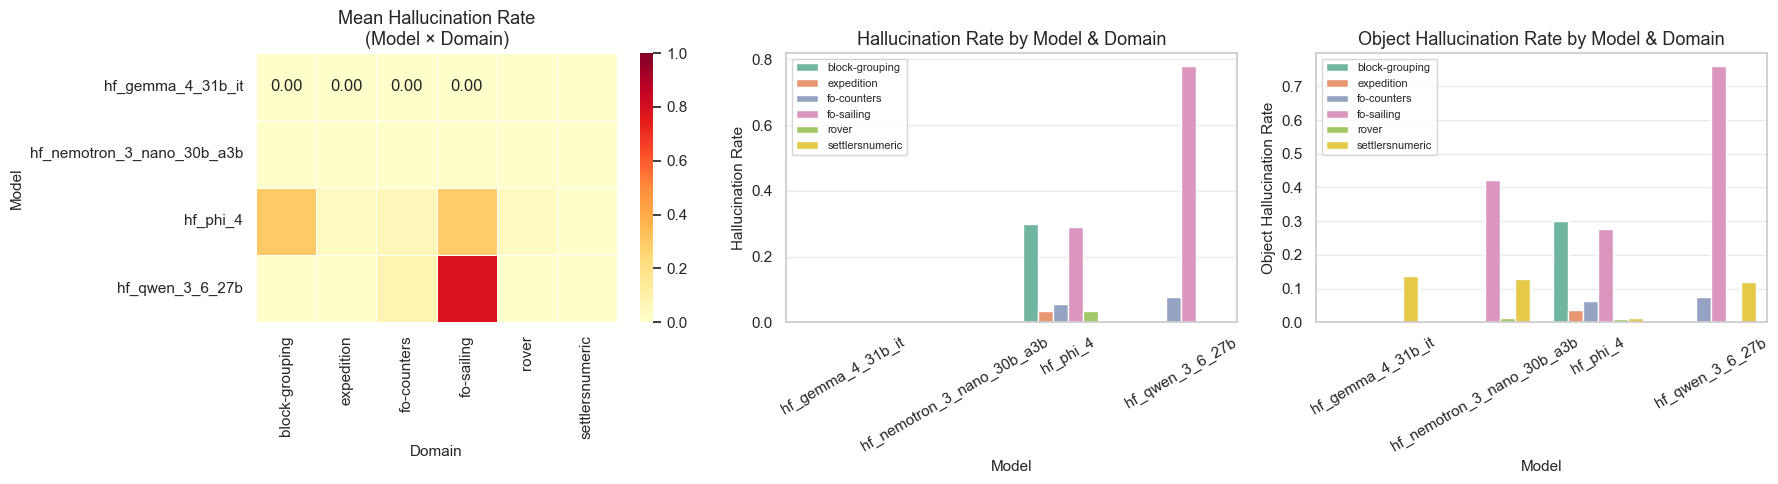


Strict vs Fuzzy Hallucination Rate:
                             Strict Halluc Rate  Fuzzy Halluc Rate  Fuzzy-Reduction
Model                                                                             
hf_gemma_4_31b_it                       0.0000             0.0000           0.0000
hf_nemotron_3_nano_30b_a3b              0.0000             0.0000           0.0000
hf_phi_4                                0.1195             0.1195           0.0000
hf_qwen_3_6_27b                         0.1426             0.1422           0.0005


In [11]:
# ── Hallucination visualisations ──────────────────────────────────────────────
if df.empty or df['hallucination_rate'].isna().all():
    print("No hallucination data available.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1) Heatmap: Model × Domain → mean hallucination_rate
    pivot = df.pivot_table(values='hallucination_rate', index='Model', columns='Domain', aggfunc='mean')
    sns.heatmap(pivot, ax=axes[0], annot=True, fmt='.2f', cmap='YlOrRd', linewidths=.5, vmin=0, vmax=1)
    axes[0].set_title('Mean Hallucination Rate\n(Model × Domain)')
    axes[0].set_xlabel('Domain'); axes[0].set_ylabel('Model')

    # 2) Bar chart: Model → mean hallucination_rate, hue=Domain
    agg = df.groupby(['Model','Domain'])['hallucination_rate'].mean().reset_index()
    sns.barplot(data=agg, x='Model', y='hallucination_rate', hue='Domain', ax=axes[1], palette='Set2')
    axes[1].set_title('Hallucination Rate by Model & Domain')
    axes[1].set_xlabel('Model'); axes[1].set_ylabel('Hallucination Rate')
    axes[1].tick_params(axis='x', rotation=30)
    axes[1].grid(axis='y', alpha=.4); axes[1].legend(fontsize=8)

    # 3) Object hallucination rate
    agg_obj = df.groupby(['Model','Domain'])['object_hallucination_rate'].mean().reset_index()
    sns.barplot(data=agg_obj, x='Model', y='object_hallucination_rate', hue='Domain', ax=axes[2], palette='Set2')
    axes[2].set_title('Object Hallucination Rate by Model & Domain')
    axes[2].set_xlabel('Model'); axes[2].set_ylabel('Object Hallucination Rate')
    axes[2].tick_params(axis='x', rotation=30)
    axes[2].grid(axis='y', alpha=.4); axes[2].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    # Strict vs fuzzy comparison table
    tbl = df.groupby('Model')[['hallucination_rate','fuzzy_hallucination_rate']].mean()
    tbl.columns = ['Strict Halluc Rate', 'Fuzzy Halluc Rate']
    tbl['Fuzzy-Reduction'] = tbl['Strict Halluc Rate'] - tbl['Fuzzy Halluc Rate']
    print("\nStrict vs Fuzzy Hallucination Rate:\n", tbl.round(4).to_string())

## 2B — Precondition Awareness Score
Simulates plan execution step-by-step, classifying failures as *sequencing errors*
(wrong order, but the predicate existed earlier) or *state fabrications* (the predicate
was never established).

In [12]:
class PDDLSimulator:
    """
    Lightweight propositional + numeric PDDL simulator.

    Supports STRIPS-style propositional state and simple numeric fluents
    (increase/decrease with constant or single-fluent amounts).
    Complex numeric expressions (nested arithmetic in preconditions) are
    evaluated on a best-effort basis; failures are treated as state fabrications.

    state machine with a memory with core self.prop tuble set where each of the tuples is a ground atom that is currently true in the world.
    everything either reads from this set( predondtion checking) or adds/removes from this set (effects) or records snapshots of this set (history for last_step_atom_true()).

    for each single action we have this procedure:
    1) grounding: it converts an action schema — which uses abstract parameter names like 
    2) precondition checking: after grounding, it checks whether every required fact is currently true in self.prop (and every numeric condition is satisfied). This is the function that determines whether an action can legally execute.
    3) effect application: if the preconditions are satisfied, the effects are applied to the current state: atoms are added or removed from self.prop, and numeric fluents are updated in self.num. The history of self.prop snapshots is updated after each step, which allows last_step_atom_true() to classify failure types based on whether the last state was valid or not.
    eval_num() runs inside both the porciotion and effect functions whenever a numeric espressione needs to be resolved toi a concrete number.
    """



    def __init__(self, d_info: Dict, p_info: Dict):
        self.d_info    = d_info
        self.prop      = set(p_info.get('init_atoms', set()))          # set of tuples each tuple is one ground atom. actions add or remove atoms from this set. it's a mutable set the worlds changes as the plan executes
        self.num       = dict(p_info.get('init_numeric', {}))          # key-tuple -> float used for PDDL domains that have numeric fluents.
        self.prop_hist = [frozenset(self.prop)]                        # history for temporal dist immutable snapshots of prop set after each step, used by last_step_atom_true() to classify failure types
        self.step      = 0

    # ── grounding It converts an action schema — which uses abstract parameter names like ?car, ?from, ?to — into a concrete expression using the actual objects from the plan. From ungrounded action schemas to grounded action instances ────────────────────────────────────────────────────────────
    def _ground(self, raw: str, params: List[str], args: List[str]) -> str:
        result = raw
        for p, a in zip(params, args):
            result = re.sub(r'\?' + re.escape(p) + r'\b', a, result)
        return result

    # ── numeric expression evaluator (best-effort) ────────────────────────────
    # It handles the right-hand side of PDDL nu meric conditions and effect values: 
    # constants, single fluent lookups, and simple arithmetic trees.
    # This is the "best-effort" policy: domains with complex fluent arithmetic that the simple evaluator cannot handle are treated as if the numeric condition is unknown — 
    # they don't block execution but they also don't validate it. 
    # For most planning domains (Citycar, Blocksworld, Tetris) the numeric expressions are simple enough that this works correctly.
    def _eval_num(self, expr: str) -> Optional[float]:
        expr = expr.strip()
        try:
            return float(expr)
        except ValueError:
            pass
        # (func arg ...)
        m = re.match(r'^\(\s*([a-z][a-z0-9_-]*)([^)]*)\)$', expr)
        if m:
            key = (m.group(1),) + tuple(m.group(2).strip().split())
            return self.num.get(key)
        # (op e1 e2) — find split at depth 0
        m2 = re.match(r'^\(\s*([+\-*/])\s(.+)\)$', expr, re.DOTALL)
        if m2:
            op, inner = m2.group(1), m2.group(2).strip()
            depth, pos = 0, 0
            operands = []
            start = 0
            for i, ch in enumerate(inner):
                if ch == '(':
                    depth += 1
                elif ch == ')':
                    depth -= 1
                elif ch == ' ' and depth == 0:
                    seg = inner[start:i].strip()
                    if seg:
                        operands.append(seg)
                    start = i + 1
            seg = inner[start:].strip()
            if seg:
                operands.append(seg)
            if len(operands) == 2:
                v1, v2 = self._eval_num(operands[0]), self._eval_num(operands[1])
                if v1 is not None and v2 is not None:
                    return {'+': v1+v2, '-': v1-v2, '*': v1*v2,
                             '/': v1/v2 if v2 else None}.get(op)
        return None # this is done since in this way the _check_preconditions() function can discard that numerico condition rather than crashing

    # ── precondition checking core judgement function. After grounding, it checks whether every required fact is currently true in self.prop (and every numeric condition is satisfied). 
    # ___This is the function that determines whether an action can legally execute.─────────────────────────────────────────────────
    def check_preconditions(self, prec_raw: str, params: List[str], args: List[str]):
        """
        Returns (satisfied: bool, failed_prop: list, failed_num: list).
        failed_prop holds tuple atoms that are missing from current state.
        failed_num  holds raw numeric condition strings that are violated.
        """
        grounded = self._ground(prec_raw, params, args)
        failed_prop, failed_num = [], []
        funcs = self.d_info.get('functions', set())
        skip_heads = {'and','or','not','>=','<=','>','<','=',
                      'increase','decrease','when','forall','exists',
                      '+','-','*','/'}

        # numeric comparisons evaluated the left hand side trough _eval_num() and compares it to the threshold on the object instance 
        for nm in re.finditer(r'\((>=|<=|>|<)\s*([^)]+)\s*([0-9.]+)\s*\)', grounded):
            op_s, lhs_s, rhs_s = nm.group(1), nm.group(2).strip(), nm.group(3)
            lhs = self._eval_num(lhs_s)
            rhs = float(rhs_s)
            if lhs is None:
                continue
            ok = {'>=': lhs>=rhs, '<=': lhs<=rhs, '>': lhs>rhs, '<': lhs<rhs}[op_s]
            if not ok:
                failed_num.append(nm.group(0))

        # propositional atoms : strips out negative conditions and checks if each positive atom is in the current state.  each atom is looked up as a tuble ins self.prop.
        no_neg = re.sub(r'\(not\s+\([^)]+\)\s*\)', '', grounded)
        for am in re.finditer(r'\(([a-z][a-z0-9_-]*)([^()]*)\)', no_neg):
            head = am.group(1)
            if head in skip_heads or head in funcs:
                continue
            atom = (head,) + tuple(am.group(2).strip().split()) if am.group(2).strip() else (head,)
            if atom not in self.prop:
                failed_prop.append(atom)

        sat = not failed_prop and not failed_num

        # returns sat : can the actiuon execute given the current state?  needed for executability_ratio metric if false the simulator stops then paln is recorded as failing at this step.
        # failed_prop: which required atoms are missing? used from PAS score the determine failure belonging to sequencing or state fabrication error
        # failed_num: which numeric conditions are violated?
        return sat, failed_prop, failed_num

    # ── effect application────────────────────────────────────────────────────
    #  called only if preconditions are satisfied. it updates the world state: adding new facts , eromving old ones , adn updating numericvalues. this is what makes time advance in the simulations
    def apply_effects(self, eff_raw: str, params: List[str], args: List[str]):
        grounded = self._ground(eff_raw, params, args)
        funcs    = self.d_info.get('functions', set())
        skip_h   = {'and','or','not','>=','<=','>','<','=',
                    'increase','decrease','when','forall','assign','+','-','*','/'}

        # delete effects: (not (pred args))
        for dm in re.finditer(r'\(not\s+\(([a-z][a-z0-9_-]*)([^)]*)\)\s*\)', grounded):
            atom = (dm.group(1),) + tuple(dm.group(2).strip().split())
            self.prop.discard(atom)

        # add effects (ignore numeric ops)
        no_del = re.sub(r'\(not\s+\([^)]+\)\s*\)', '', grounded)
        for am in re.finditer(r'\(([a-z][a-z0-9_-]*)([^()]*)\)', no_del):
            head = am.group(1)
            if head in skip_h or head in funcs:
                continue
            atom = (head,) + tuple(am.group(2).strip().split()) if am.group(2).strip() else (head,)
            self.prop.add(atom)

        # numeric effects: (increase (func args) val) / (decrease ...)
        for op_name in ('increase', 'decrease'):
            for nm in re.finditer(
                    r'\(' + op_name + r'\s+\(\s*([a-z][a-z0-9_-]*)([^)]*)\)\s*([0-9.]+|\([^)]+\))\s*\)',
                    grounded):
                key = (nm.group(1),) + tuple(nm.group(2).strip().split())
                val = self._eval_num(nm.group(3).strip())
                if val is not None:
                    if op_name == 'increase':
                        self.num[key] = self.num.get(key, 0.0) + val
                    else:
                        self.num[key] = self.num.get(key, 0.0) - val

        self.prop_hist.append(frozenset(self.prop)) # snapshot of the new state after applying effects, used for temporal history queries this is the data structure that feeds the temporal distance calculation in PAS metric
        self.step += 1

    # ── temporal history queries ──────────────────────────────────────────────
    # function that powers the PAS (Precondition Awareness Score). 
    # When an action fails because atom X is not in the current state, 
    # it searches backward through the history to find out: was X ever true? If yes — when?
    # functioning 
    # i>0 Atom was true at step i, then got deleted before current step meaning that a it tried to do an action too late w.r.t. to the state in which the preconditions(atom) was true shou--> sequencing error --> moderate - model knew what was needed but got the order wrong
    # i=-1 Atom was never true in the history --> state fabrication error --> severe -model invented a precondition that never existed 
    # i = 0 Atom was true in intial state bnut got deleted early --> sequencing error --> moderate 
    def last_step_atom_true(self, atom) -> int:
        """Return the most recent step where atom held, or -1 if never."""
        for i in range(len(self.prop_hist) - 1, -1, -1):
            if atom in self.prop_hist[i]:
                return i
        return -1

print("PDDLSimulator defined.")

PDDLSimulator defined.


In [13]:
def compute_precondition_metrics(actions: List[str], d_info: Dict, p_info: Dict,
                                  label: str = '') -> Dict:
    """
    orchestrator PDDL simulator only knows how to simulate one action at a time, no concept of a full plan , failure points or output metrics.
    Simulate plan execution wrapping the simulator in a loop and compute precondition-awareness metrics.
    

    Input:
        actions - list of raw action strings
        d_info  - domain info dict
        p_info  - problem info dict
        label   - used only for warning messages

    Output: dict with
        executability_prefix_length: step index of the first failure (only for diagnostic), 
        executability_ratio: exec_ratio componet in PS metric,
        sequencing_error_count: PAS numerator component, 
        state_fabrication_count: PAS denominator component,
        precondition_awareness_score: PAS component in PS metric, 
        mean_temporal_distance : dept of sequencing errors ( diagnostic only )
           |->A distance of 1 means the model was almost right — the required atom was deleted just one step earlier, a near-miss. 
           |->A distance of 10 means the model placed the action in a completely wrong part of the plan relative to when the world was in the needed state.

    Classifies failures:
        sequencing_error   - precondition predicate was true at some earlier step
        state_fabrication  - predicate was never established in any prefix state
    """
    nan_result = dict(
        executability_prefix_length = 0,
        executability_ratio         = float('nan'),
        sequencing_error_count      = 0,
        state_fabrication_count     = 0,
        precondition_awareness_score= float('nan'),
        mean_temporal_distance      = float('nan'),
    )
    #guard 1 - empty plan → all metrics are nan or 0 as appropriate
    n = len(actions)
    if n == 0:
        return nan_result

    try:
        sim = PDDLSimulator(d_info, p_info)
        schemas = d_info.get('schemas', {})

        first_failure = n
        seq_errs, fab_errs = 0, 0
        temporal_dists: List[float] = [] #it is a list of distances across multiple simultaneously violated preconditions at the single failing step.
        #  main loop iterates over every action string in the plan:
        # 1) parse it
        # 2) call PDDLSimulator check_precondition method
        # 3) record only first failure
        # 4) classify biolated precondition

        for step, act_str in enumerate(actions):
            aname, aargs = parse_action(act_str)
            if aname is None:
                continue
            #guard 2 - unknown action → skip without failing, this allows the simulator to process plans with hallucinated actions and still extract useful information from the parts of the plan that are valid
            schema = schemas.get(aname)
            if schema is None:
                continue  # unknown action — skip without failing is done since without advancing first_failure. deliberate choice in order to not count those failers in the PAS metric two times

            params   = schema.get('params', [])
            prec_raw = schema.get('prec_raw', '')
            eff_raw  = schema.get('eff_raw', '')
            #guard 3 - argument count mismatch → count as fabrication error, this is a strong signal that the model got the action schema wrong and is inventing effects and preconditions that don't align with any real action in the domain
            if len(params) != len(aargs):
                if first_failure == n:
                    first_failure = step #only record the first fail
                fab_errs += 1
                break # count as state fabrication and stop execution since the grounding is unreliable from this point on

            sat, failed_prop, failed_num = sim.check_preconditions(prec_raw, params, aargs)

            if not sat:
                if first_failure == n:
                    first_failure = step
                for atom in failed_prop:
                    last = sim.last_step_atom_true(atom)
                    if last >= 0:
                        seq_errs += 1
                        temporal_dists.append(step - last)
                    else:
                        fab_errs += 1
                fab_errs += len(failed_num)  # numeric failures → fabrication
                break

            sim.apply_effects(eff_raw, params, aargs)

        total_fail = seq_errs + fab_errs
        return dict(
            executability_prefix_length  = first_failure,
            executability_ratio          = first_failure / n,
            sequencing_error_count       = seq_errs,
            state_fabrication_count      = fab_errs,
            precondition_awareness_score = seq_errs / total_fail if total_fail > 0 else float('nan'),
            mean_temporal_distance       = float(np.mean(temporal_dists)) if temporal_dists else float('nan'),
        )
    except Exception as e:
        warnings.warn(f"[simulator] {label}: {e}")
        return nan_result

print("compute_precondition_metrics() defined.")

compute_precondition_metrics() defined.


## Integrating precondition metrics into `df`

### DataFrame row structure
Each row in `df` has three fields: `Domain`, `problem`, and `difficulty`.

Access the domain with `row.Domain`.

### Domain info (`domain_info`)
Keyed by **domain name**. Each entry contains:
- `schemas`
- `predicates`
- `funcs`

dictionary built when the PDDL file where parsed.
### Problem info (`problem_info`)
Keyed by the **tuple `(domain, difficulty, instance)`**, e.g.:

```python
problem_info[(domain, diff, inst)]
```

> Using a 3-part key is necessary because different difficulty levels may share instance names.

Each entry contains:
- `init_atoms`
- `objects`
- `goal`

dictionary buildt when the PDDL files were parsed.

In [14]:

prec_rows = []
for _, row in df.iterrows():
    #row content
    dom  = row['Domain']
    inst = row['Problem']
    diff = row.get('Difficulty', 'unknown')
    # key: domanin name string 
    dinfo = domain_info.get(dom, {})
    # key : (domain name string, difficulty string, problem instance string)
    pinfo = problem_info.get((dom, diff, inst), {})
    # we compute precoditiuon metrics for each row passing action list, domain info and problem info
    pm = compute_precondition_metrics(row['_actions'], dinfo, pinfo, label=row['_file_path'])
    #collect the dictionrary of 6 precondition metrics for each df row in a list
    prec_rows.append(pm)

#convert the list of dicts into a padas dataframe and concatenate it to the original df column-wise, this way we have all the original columns plus the new precondition metrics columns in a single dataframe for analysis and visualisation
prec_df = pd.DataFrame(prec_rows)
df = pd.concat([df.reset_index(drop=True), prec_df.reset_index(drop=True)], axis=1) #joinn the two dataframes column-by-colums 
print("Precondition columns added:", prec_df.columns.tolist())

Precondition columns added: ['executability_prefix_length', 'executability_ratio', 'sequencing_error_count', 'state_fabrication_count', 'precondition_awareness_score', 'mean_temporal_distance']


# Plots for PAS and `executability_ratio` metrics

## Executability ration by model and domain ( box plot ):
- 'Bottom edge = 25th percentile (Q1).'

- 'Top edge = 75th percentile (Q3).'

- 'Middle line = median.'

- 'Whiskers = 1.5×IQR.' 

- 'Dots beyond whiskers = outliers.'

### what to look for:
- Box near 1.0 = model runs most of the plan before any failure —>it understands the domain structure.
- Box near 0.0–0.2 = model fails at step 1 or 2 —> near-total domain incomprehension.
- IQR value hight inconsistent —> model works on some problems but collapses on others. 
- IQR value low model is consistent 

ideally we want a model to have a narrow box ( small IQR ) with a high position possibily for all the domains this means that the model is consistently good , most plans runs before failing and the variation is small.

the top and bottom whiskers discriminate point that are still within the expectable largest and lowest point , all the points above and below those thresholds are threated as outliers.

`executability_ratio` is a prerequisite for PAS to be meaningful. A model with exec_ratio near 0 has nothing to classify : it fails before any causal structure can be tested. 

PAS only becomes informative when `executability_ratio` is moderate-to-high (0.4+), because only then has the model actually engaged with the domain's state-transition logic long enough for its causal reasoning to be observable for values near zero PAS will be nearly always NaN because the plan never executes long enogh to trigger a classifiable precondition failure.

this plot make possible to compare cross-model , cross-domain LLM familiy performances following the same logic , possible consideration that could be done:

- per model cross-domain comparation we have to look to different colored boxes withing one cluster then using the meaning of the box posed before we could look at the LLM performances across different domains from this we could exstrapolate an idea of the LLM capabilities of solving reasoning problems in different scenarios.

- per domain cross-model comparation we have to look to same colored boxes across all domains then looking performances of each LLM on the specific domain from this we could exstrapolate an idea of the real difficulty of the problem. 


## failure type breakdown per model ( stacked bar ):

for each model we compute raw total errors across all domains and problems then convert it to proportions by dividing each row by it's total.

models with zero total failures are handled by putting a flat zero bar rathen than NaN.

the result is a proportion , not an absolute count , so models with different numbers of runs are still comparable.

### how to read the plot:

- BLUE-> sequencing errors : the model knew what precondition was needed , the required atom ( single grounded propositional fact , a precondition is a conjunction of several atoms) was true earlier , but placed the action too late after it had been deleted by a prior `apply_effects` call. A tall blue bar means the model has a reasonable causal model of the domain. The failures are ordering mistakes, not conceptual ones. These are more fixable with better prompting.

- RED -> state fabrication : the required atom was never true in any previous state. the model referenced a world fact the domain never established it invented a precondition. A tall red bar means the model has no grounded world model. This is the more severe failure mode and is less fixable through prompting alone.


## executability ration vs plan lenght ( scattera plot ):

the same model may show a decay slope in one domain ( complex state interaction ) but stay flat hight in another ( simpler structure ). faceting by domain separate these effects.

if a model decays in every domain there is a a problem with foundamental state tracking capacity.

if it decays only in one domain , the problem is domain specific.

### The decay slope is the key diagnostic
A negative correlation between plan length and exec_ratio is exactly the prediction made by Dziri et al. (NeurIPS 2023, "Faith and Fate: limits of transformers on compositionality"): transformer models lose causal coherence as the computation graph deepens.

- robust internal model : executionability_ration stays high regardless of plan lenght
- state tracking decay : ratio drops as lenght grows = state tracking collapse giving a sense of LLM relying more on it's generated output chain than a strong internal model rappresentation ( to this maybe could be useful elaborate more using a new metric to evaluate this thing based on Vafa et.al "Evaluating the World model implicit in a generative Model" paper based on Myhill-Nerode theorem in language theory that could be a generalization of the PAS score implemented up to now )
- little-to-no domain knowledge : ration flat near 0 always , no domain knowledge or domain not read.


## mean temporal distance per model ( histogram )

the distribution of high frequence mean temporal distances is related to the causal model internalization of the LLM. 

Each bar on the Histogram represents a group of plans whose sequencing errors had that average temporal dinstance.

Distance = ( step at which first failure happened ) - ( last step where violated atom was true ) 

since each precodition is composet of more atoms at a step we do a mean of all the distance values for each precondition.

some models could not have histogram rappresentation, since a model where `mean_temporal_distance` is always NaN produces no histogram panel. this happens when all model's failures are state fabrications , there are no sequencing errors to compute distance for. The absence of the panel is informative it means that for a specific model PAS = 0.0.


### distribution shape possible interpretation

- spike at 1-2 : Near-miss ordering: model almost gets it right, just one step too late severity: low
- spike at 3-7 : Imprecise causal model: knows what's needed but tracks sequence loosely severity: moderate
- Long tail 8+ : Severe ordering collapse: preconditions were true much earlier in the plan severity : high
- No bars(NaN) : All failures are fabrications ,model has no causal knowledge at all severity : severe

Read all four together by asking a single cascading question: 

1) does the plan run at all (Plot 1)?

2) when it fails, is it a conceptual or ordering error (Plot 2)? 

3) does the failure pattern worsen with problem complexity (Plot 3)? 

4) how severe are the ordering errors that do occur (Plot 4)? 

A model that passes Plot 1, has mostly blue in Plot 2, stays flat in Plot 3, and shows a spike at distance 1 in Plot 4 is a model that genuinely understands the domain and makes only minor sequencing mistakes. 

A model that fails Plot 1 and has no histogram in Plot 4 is fabricating preconditions from the first step  it maybe not planning at all.


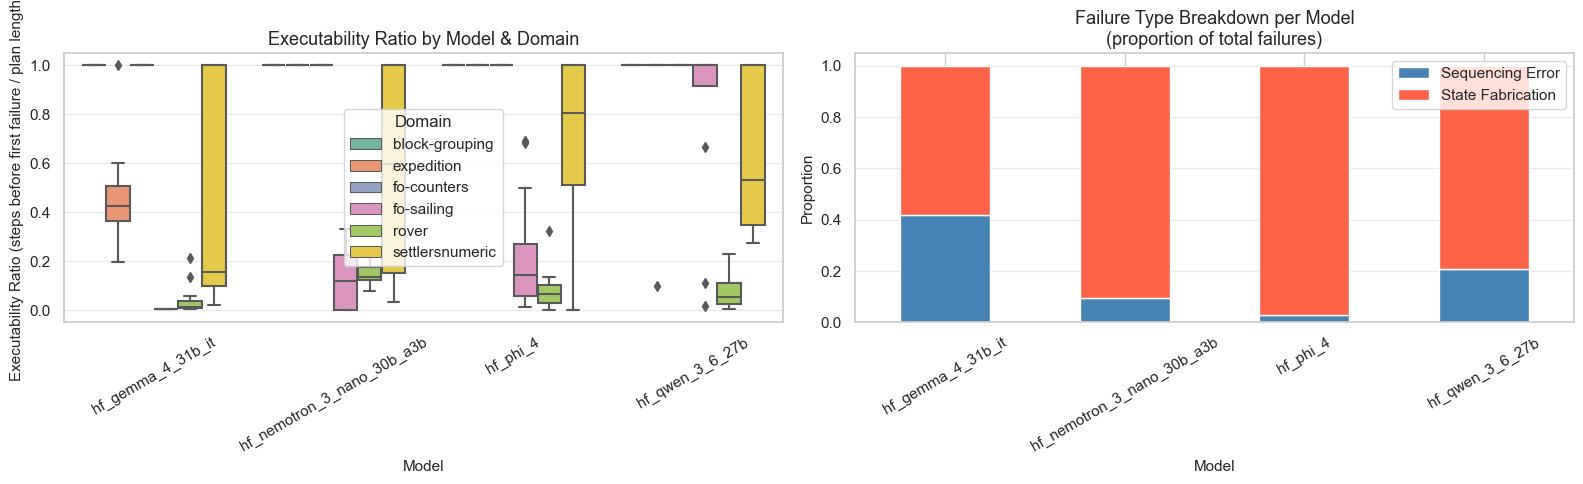

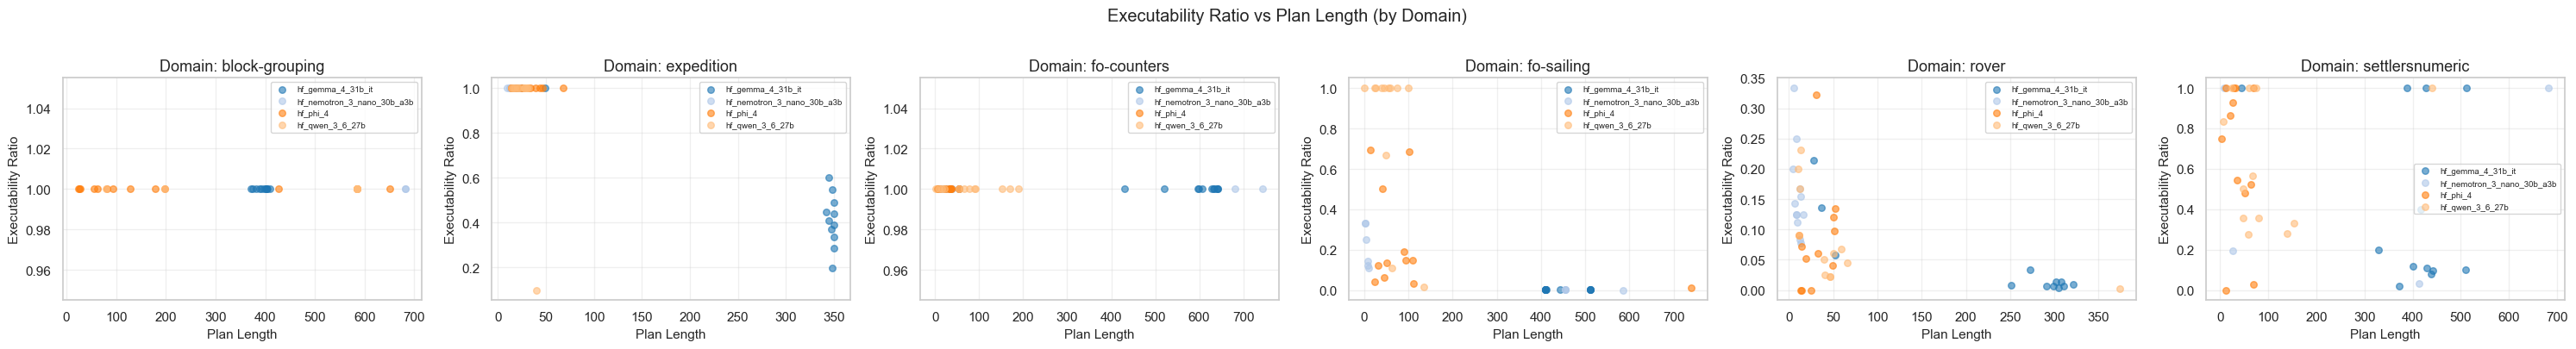

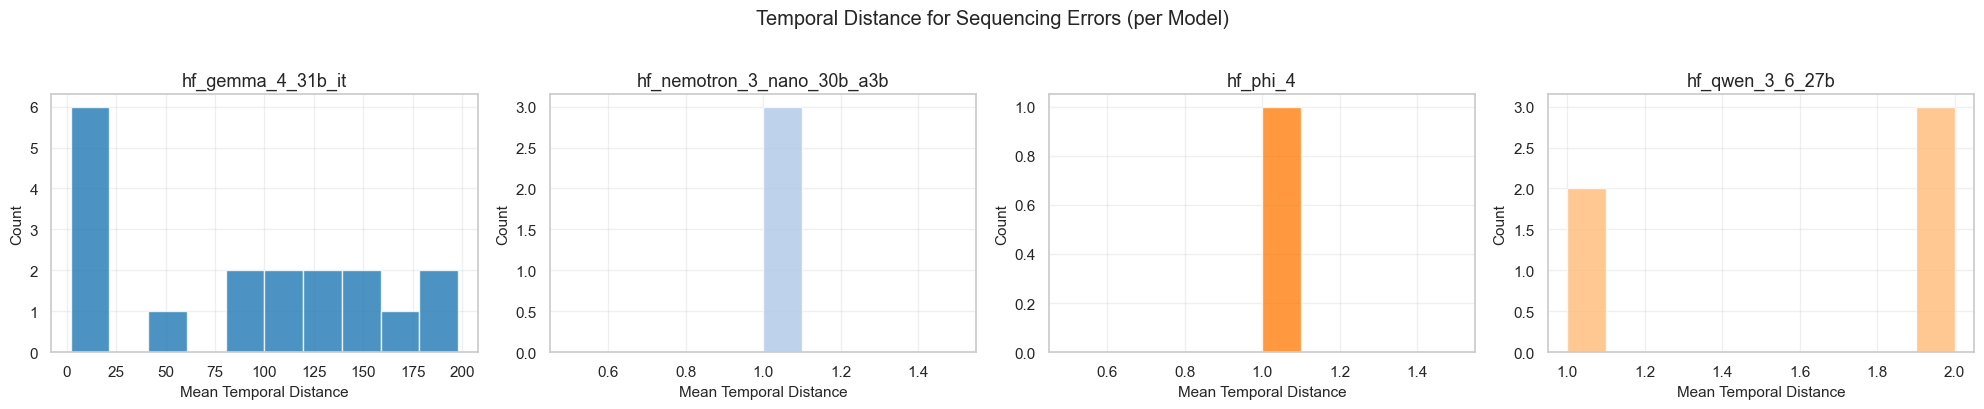

In [15]:
if df.empty or df['executability_ratio'].isna().all():
    print("No precondition data available.")
else:
    # 1) Box plot: executability_ratio by Model & Domain
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.boxplot(data=df.dropna(subset=['executability_ratio']),
                x='Model', y='executability_ratio', hue='Domain',
                ax=axes[0], palette='Set2')
    axes[0].set_title('Executability Ratio by Model & Domain')
    axes[0].set_xlabel('Model'); axes[0].set_ylabel('Executability Ratio (steps before first failure / plan length)')
    axes[0].tick_params(axis='x', rotation=30); axes[0].grid(axis='y', alpha=.4)

    # 2) Stacked bar: sequencing_error vs state_fabrication per model
    err_agg = df.groupby('Model')[['sequencing_error_count','state_fabrication_count']].sum()
    err_agg_pct = err_agg.div(err_agg.sum(axis=1), axis=0).fillna(0)
    err_agg_pct.plot(kind='bar', stacked=True, ax=axes[1],
                     color=['steelblue','tomato'], edgecolor='white')
    axes[1].set_title('Failure Type Breakdown per Model\n(proportion of total failures)')
    axes[1].set_xlabel('Model'); axes[1].set_ylabel('Proportion')
    axes[1].tick_params(axis='x', rotation=30); axes[1].grid(axis='y', alpha=.4)
    axes[1].legend(['Sequencing Error','State Fabrication'])
    plt.tight_layout(); plt.show()

    # 3) Scatter: executability_ratio vs plan length, coloured by model, faceted by domain
    doms = df['Domain'].dropna().unique()
    ncols = max(1, len(doms))
    fig2, axes2 = plt.subplots(1, ncols, figsize=(5*ncols, 4), squeeze=False)
    for ax, dom in zip(axes2[0], doms):
        sub = df[df['Domain'] == dom].dropna(subset=['executability_ratio','Length'])
        for model, grp in sub.groupby('Model'):
            ax.scatter(grp['Length'], grp['executability_ratio'],
                       label=model, alpha=.6, s=30,
                       color=MODEL_PALETTE.get(model, 'gray'))
        ax.set_title(f'Domain: {dom}'); ax.set_xlabel('Plan Length')
        ax.set_ylabel('Executability Ratio'); ax.grid(alpha=.3); ax.legend(fontsize=7)
    plt.suptitle('Executability Ratio vs Plan Length (by Domain)', y=1.01)
    plt.tight_layout(); plt.show()

    # 4) Histogram of temporal distance per model
    td_data = df.dropna(subset=['mean_temporal_distance'])
    if not td_data.empty:
        models_td = td_data['Model'].unique()
        nc = max(1, len(models_td))
        fig3, axes3 = plt.subplots(1, nc, figsize=(5*nc, 4), squeeze=False)
        for ax, model in zip(axes3[0], models_td):
            sub = td_data[td_data['Model'] == model]['mean_temporal_distance']
            ax.hist(sub.dropna(), bins=10, color=MODEL_PALETTE.get(model, 'steelblue'),
                    edgecolor='white', alpha=.8)
            ax.set_title(f'{model}'); ax.set_xlabel('Mean Temporal Distance')
            ax.set_ylabel('Count'); ax.grid(alpha=.3)
        plt.suptitle('Temporal Distance for Sequencing Errors (per Model)', y=1.02)
        plt.tight_layout(); plt.show()

## 2C — CoT–Plan Alignment Score
Measures how well the chain-of-thought reasoning reflects the actions and objects
that actually appear in the final plan.

responding to the question:

does the model's chain-of-though reasoning actually talk about the same things that end up in the plan?

- If the CoT mentions the right actions and objects, that is evidence the reasoning was guiding the plan generation. --> high score

- If the CoT mentions entirely different things, the reasoning is decorative, the plan was generated by some other mechanism and the CoT was written around it afterwards. --> low score

Kambhampati (Kambhampati (2024) "Can Large Language Models Reason and Plan?") calls this the difference between "fake reasoning" and genuine deliberation: a model can produce a correct plan from memory or pattern-matching and then generate a plausible-sounding explanation around it.

Lanham et al.(Lanham et al. (2023) "Measuring Faithfulness in Chain-of-Thought Reasoning") showed empirically that as models get larger, their CoT becomes less faithful , the reasoning trace increasingly diverges from whatever process actually produced the answer. This function directly operationalises faithfulness measurement in our PDDL setting.

### alignement evaluation what is computed and why:

double intersection procedure:

- The first intersection  filters CoT tokens to only those that are valid action names in the domain
- The second intersection then further filters to only those objects that actually appear in the plan

This two-step filter is necessary because:

- Without the first filter : A word in natural language text would match the action name if the tokeniser is loose. Any English word that happens to resemble a PDDL action name would inflate the score. The first filter restricts to tokens that are exact members of legal_action_names (the formally defined domain vocabulary).
- Without the second filter : A CoT that mentions every action in the domain vocabulary would score 1.0 even if the plan only uses one action. The second filter requires the CoT to mention specifically the actions that were actually used, not just known domain vocabulary.

### Example :


#### cot_text (what the model wrote as reasoning)

"I need to move car1 from location l1 to l2 along the road. Once car1 is at l2, I can pick up passenger p1. Then I should drive to l3 to drop off the passenger."

#### actions 

(move-car car1 l1 l2) (pick-up p1 car1 l2) (move-car car1 l2 l3) (drop-off p1 car1 l3)

in this case we get full actions and object coverage since all fully mentioned in the CoT natural language expressed action sequence.

### coverage scores denominator choices

the denominator of each coverage formula is the size of the plan vocabulary not the CoT vocabulary. this is a deliberate design choice. We wanted to find the fraction of all the plan actions/objects that we could find in the CoT reasoning text not the fraction of  all the CoT actions/objects that made it into the plan. Using plan based denominator value tries to eliminate the possibility of a model generating a very long CoT mentioning everything and still having an inflated Cot_alignement score. the score rewards coverage of whjat was actually done , not verbose enumeration of possibilities.


### Scores Evaluation 
# CoT Alignment Score — Scenario Reference

| Scenario | `cot_action_cov` | `cot_object_cov` | What it reveals |
|---|:---:|:---:|---|
| CoT names every action and object in the plan | **1.00** | **1.00** | Perfect alignment the CoT anticipated the plan |
| CoT names all actions but wrong objects | **1.00** | **0.00** | Model knows what to do but reasons about wrong locations/objects |
| CoT names some actions, all objects | **0.50** | **1.00** | Object tracking good, action selection partially off |
| CoT names no domain actions or objects | **0.00** | **0.00** | CoT is pure natural language with no PDDL grounding |
| Plan is empty (no valid actions parsed) | **0.00** | **0.00** | `max(0,1)=1` in denominator prevents division by zero → `0/1 = 0.0` |
| CoT is empty string | **0.00** | **0.00** | `cot_tokens` is empty set, both intersections are empty |



### maybe limited approach on the tokenizer

The tokeniser uses re.findall(r'[a-z][a-z0-9_-]*', cot_lower). This finds substrings matching the pattern , it does not do word-boundary matching. If the CoT contains the phrase "pick-up-person" and the domain action is "pick-up", both tokens are extracted and the shorter one will match. This means the score can be slightly inflated when action names are substrings of longer compound words in the CoT. In practice this is rare in PDDL domains where action names are specific, but it is worth noting when interpreting very high scores.



In [16]:
def compute_cot_alignment(cot_text: str, actions: List[str],
                           d_info: Dict, p_info: Dict) -> Dict:
    """
    Compute CoT-plan alignment score for one plan.

    Input:
        cot_text - chain-of-thought reasoning text extracted from plan file
        actions  - list of raw action strings in the final plan
        d_info   - domain info dict
        p_info   - problem info dict

    Output: dict with
        cot_action_coverage, cot_object_coverage, cot_alignment_score

    Detects: whether the model's reasoning references the actions and objects
    it later uses, indicating genuine planning vs post-hoc generation.
    """
    # inputs from d_info and p_info (same dicts as PDDLSimulator uses) 
    legal_action_names = d_info.get('action_names', set())
    legal_objects      = p_info.get('objects', set())

    # tokenise the CoT text 
    cot_lower          = cot_text.lower()
    cot_tokens         = set(re.findall(r'[a-z][a-z0-9_-]*', cot_lower))
    # extracts every word/identifier token from the CoT as a set of lowercase strings, this is a very permissive tokenisation that captures any potential reference to actions or objects even if the CoT is not well-structured or uses different formatting than the final plan. 
    # it is designed to maximise recall of relevant mentions in the CoT, at the cost of potentially including some irrelevant tokens. this is intentional since we want to capture any possible alignment signal from the CoT even if it's noisy.

    # plan action names and arguments
    plan_anames, plan_objs = set(), set()
    for act in actions:
        n, args = parse_action(act) # same parse_action used everywhere
        if n:
            plan_anames.add(n) # unique action names used in the plan
            plan_objs.update(args) # all object arguments appearing in plan

    # intersect CoT tokens with legal vocabulary 
    cot_act_mentioned = cot_tokens & legal_action_names
    cot_obj_mentioned = cot_tokens & legal_objects


    # compute the two coverage scores 
    cot_action_cov = len(cot_act_mentioned & plan_anames) / max(len(plan_anames), 1)
    cot_object_cov = len(cot_obj_mentioned & plan_objs)  / max(len(plan_objs),   1)
    cot_align      = (cot_action_cov + cot_object_cov) / 2

    return dict(
        cot_action_coverage  = cot_action_cov,
        cot_object_coverage  = cot_object_cov,
        cot_alignment_score  = cot_align,
    )

print("compute_cot_alignment() defined.")

compute_cot_alignment() defined.


In [17]:
cot_rows = []
for _, row in df.iterrows():
    # check if CoT is present for this row, either via explicit protocol flag or by presence of non-empty CoT text. 
    # this allows us to compute CoT alignment metrics only for the subset of plans where we have CoT data, without crashing on rows that don't have it.
    cot_flag = str(row.get('Chain_of_Thought', '')).lower() in ('true', '1', 'yes')
    # done in order to try to compute CoT alignement only for rows which have the flag active
    if cot_flag:
        dinfo = domain_info.get(row['Domain'], {})
        diff  = row.get('Difficulty', 'unknown')
        pinfo = problem_info.get((row['Domain'], diff, row['Problem']), {})
        try:
            cm_ = compute_cot_alignment(row['_cot_text'], row['_actions'], dinfo, pinfo)
        except Exception as e:
            warnings.warn(f"CoT error {row['_file_path']}: {e}")
            cm_ = dict(cot_action_coverage=float('nan'),
                       cot_object_coverage=float('nan'),
                       cot_alignment_score=float('nan'))
    else:
        cm_ = dict(cot_action_coverage=float('nan'),
                   cot_object_coverage=float('nan'),
                   cot_alignment_score=float('nan'))
    cot_rows.append(cm_)

cot_df = pd.DataFrame(cot_rows)
df = pd.concat([df.reset_index(drop=True), cot_df.reset_index(drop=True)], axis=1)
print("CoT columns added:", cot_df.columns.tolist())

CoT columns added: ['cot_action_coverage', 'cot_object_coverage', 'cot_alignment_score']


# plots for CoT alignement 

## mean CoT alignement bt model and domain ( bar chart )
For each model is taken the mean CoT alignement score . it hides variance , so it's the first thing to look at before going to the violin plot. A mean alignment of 0.60 could mean every plan scored around 0.60 (consistent moderate alignment), or it could mean half the plans scored 1.0 and half scored 0.2 (bimodal — some runs perfectly aligned, others completely disconnected). The violin plot resolves this ambiguity. Always look at both together.

### model across all domains comparison
compare domain bars for the same model:
- similar mean CoT alingnement value and high -> domain general reasoning : CoT grounding consisent across domains , formal domain vocabolary is used regardless of which domain is operating in .
- very dissimiliar mean CoT alignements -> domain specific behaviour : could mean CoT grounding in one or more domains but falling into natural language in others, which is a sort of domain transfer failure.
- similar mean CoT alignement value and low -> CoT not grounded in PDDL vocabulary

### domain across model groups
compare domain bar for different models:
we could exstrapolate qualitative information about the difficulty of a domain for CoT to ground in . could be harder action names or objects identifiers for the LLMs to recognise and repeat in reasoning text.


## success rate CoT = True vs CoT = False ( side-by-side bars )
The code creates a boolean flag _cot_flag from the Chain_of_Thought column, groups by model and flag, and takes the mean of Valid which is success rate. The two bars per model show the success rate when CoT was enabled vs disabled for the same model on the same problems.

### how to interpret results 

| Pattern | What you see | Scientific conclusion |
|---|---|---|
| **CoT=True > CoT=False** | Blue bar taller than red | CoT is causally improving planning. Cross-check: does alignment score correlate with the gap? Stechly would predict this only if alignment is also high. Even if CoT=True produces higher success rates, that improvement is only evidence of genuine reasoning if the CoT alignment score is also high. If success goes up but alignment is low, the CoT is not what improved the outcome (Stechly, K., Marquez, M., & Kambhampati, S. (2023).*GPT-4 Doesn't Know It's Wrong: An Analysis of Iterative Prompting for Reasoning Problems.*) |
| **CoT=True < CoT=False** | Red bar taller than blue | CoT is actively harmful the model's reasoning confuses its own plan generation. This can happen when the model generates a verbose CoT that contradicts itself before writing the plan. |
| **CoT=True ≈ CoT=False** | Bars at same height | CoT is decorative it has no effect on planning success. This is Kambhampati's,(S. (2024). *Can Large Language Models Reason and Plan? ) *"fake reasoning"* scenario: plans are retrieved by pattern matching and CoT is generated around them afterwards. |
| **Both bars low** | Both bars near 0 | Model cannot plan in this domain regardless of CoT. CoT effect size is not interpretable when baseline performance is near floor. |

### what to take into account : experiment control

The CoT=True and CoT=False runs may not be testing the same problems, or may have been generated with different prompts, temperatures, or iteration budgets ( max number of attemps). If the experimental design did not deliberately hold all other variables equal while varying only the CoT flag, the difference between the bars could reflect those confounds rather than a true CoT effect.

#### temperature parameter
When an LLM generates text, at every step it produces a probability distribution over its entire vocabulary every possible next token gets assigned a score. Before sampling from that distribution, the scores are divided by the temperature value. This division changes the shape of the distribution:
adjusted_probability = original_score / temperature

- Temperature = 1.0 : the distribution is used as-is, unchanged from what the model learned
- Temperature < 1.0 : dividing by a small number makes the high-probability tokens relatively even more dominant and low-probability tokens nearly impossible. The distribution becomes sharper, more peaked .The model picks the most likely tokens almost every time.
- Temperature > 1.0 : dividing by a large number flattens the distribution. High and low probability tokens become more similar in likelihood. The model picks surprising, unusual tokens more often.

to have a benchmark to be consistent/reproducible is better to put for all LLMs 0 or a very low value in order to ensure that differeces that could be seeh between models reflect capability and not random solution sampling in both CoT = TRUE and FALSE runs.

#### iteration budget parameter

following valmeekam et al. (2023) (Valmeekam et al. (2023) — NeurIPS, "On the Planning Abilities of Large Language Models: A Critical Investigation") we set a maximum iteration budget of N rounds. Following Stechly et al. (2023) (Stechly, Marquez & Kambhampati (2023) — "GPT-4 Doesn't Know It's Wrong") we treat iterations beyond the first as independent samples rather than genuine corrections, and use FASR and IWSR to distinguish models that plan correctly from models that succeed only through repeated sampling. The recommended and defensible values are between 3 and 15 iterations since stechly et al.'s result implies the marginal value of additional iterations after the first few is negligible.

as the parameter before the number has to be maintained consistent across the CoT TRUE and FALSE runs.


## Cot alignement distribution for valid and invalid plans

the violin plot shows the distribution shape of alignement scores split by plan validity.

Compare the median line positions (middle inner line) between Valid and Invalid violins. If the Valid median is substantially higher than the Invalid median, CoT alignment is predictive of success models that reason in domain vocabulary are more likely to produce valid plans. If the medians are at the same height, alignment and validity are independent the model's reasoning quality does not determine its planning outcome.

### how to look at the violin plot ( too look a bit since the violin plot does a KDE and is not soo good due to the way the CoT alignement scores are distributed )

the violin plot is just a rotated of 90° counterclockwise and smoothed histogram. In this particular case we have that the histogram that is mapped contains on the x axis the values of CoT alignement score and on the y axis the number of plans that fall

we have to look at the characteristics of the violin plots in order to exstrapolate some useful informations lookig at the difference between valid and invalid plans Violin plots for example:

| Pattern | Valid Violin | Invalid Violin |  Possible Conclusion |
|---------|-------------|----------------|------------|
| Model A  | Tight, high mass near 1.0 | Wide, spread across 0–1 | Valid plans have consistently aligned CoT. Failed plans have chaotic CoT no relationship between reasoning and output. |
| Model B  | Moderately tight, high | Only slightly lower, similar width | CoT stays grounded even in failed plans. Failures are not due to CoT misalignment likely sequencing errors or domain complexity, not reasoning failure. |
| Model C  | Very wide, centred mid-range | Wide, similar to Valid | CoT is noisy for both outcomes. The model neither reasons consistently when it succeeds nor fails in a coherent pattern. Alignment is essentially random. |


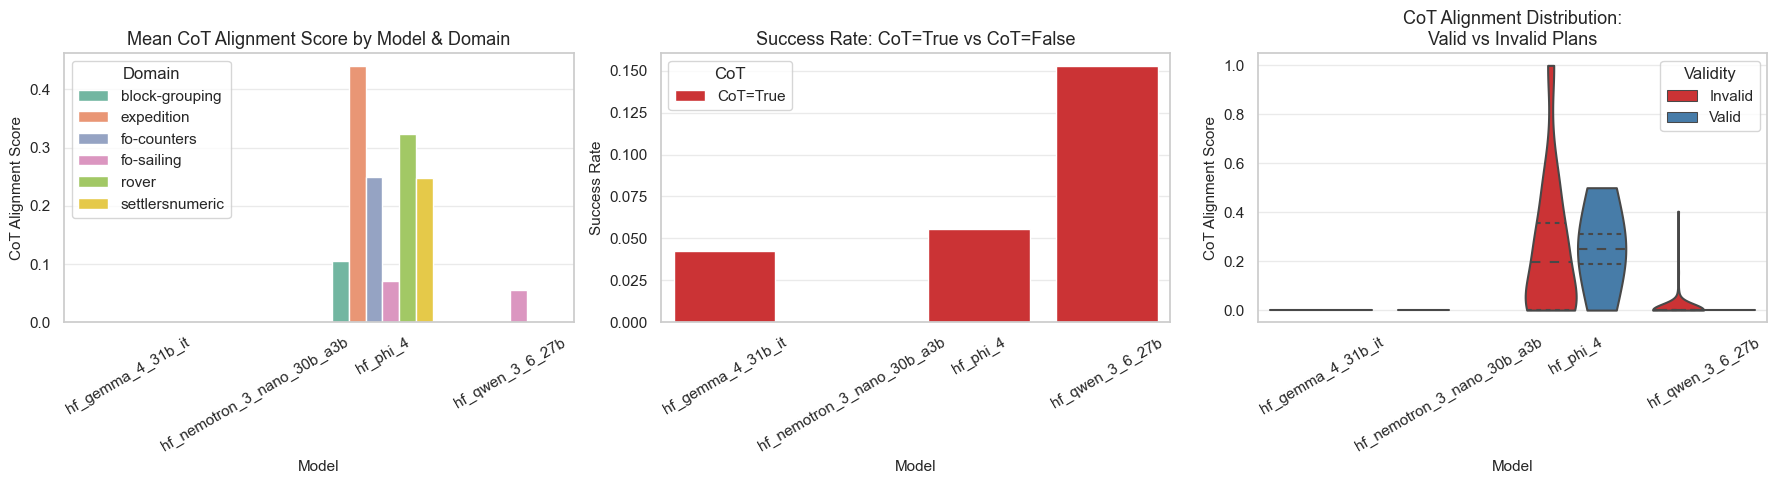

In [18]:
if df.empty or df['cot_alignment_score'].isna().all():
    print("No CoT data available.")
else:
    cot_sub = df.dropna(subset=['cot_alignment_score'])

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1) Bar chart: mean cot_alignment_score per Model, hue=Domain
    agg = cot_sub.groupby(['Model','Domain'])['cot_alignment_score'].mean().reset_index()
    sns.barplot(data=agg, x='Model', y='cot_alignment_score', hue='Domain',
                ax=axes[0], palette='Set2')
    axes[0].set_title('Mean CoT Alignment Score by Model & Domain')
    axes[0].set_xlabel('Model'); axes[0].set_ylabel('CoT Alignment Score')
    axes[0].tick_params(axis='x', rotation=30); axes[0].grid(axis='y', alpha=.4)

    # 2) Side-by-side: Success Rate for CoT=True vs CoT=False per model
    df['_cot_flag'] = df['Chain_of_Thought'].apply(lambda x: str(x).lower() in ('true','1','yes'))
    cot_sr = df.groupby(['Model','_cot_flag'])['Valid'].mean().reset_index()
    cot_sr['CoT'] = cot_sr['_cot_flag'].map({True:'CoT=True', False:'CoT=False'})
    sns.barplot(data=cot_sr, x='Model', y='Valid', hue='CoT', ax=axes[1], palette='Set1')
    axes[1].set_title('Success Rate: CoT=True vs CoT=False')
    axes[1].set_xlabel('Model'); axes[1].set_ylabel('Success Rate')
    axes[1].tick_params(axis='x', rotation=30); axes[1].grid(axis='y', alpha=.4)

    # 3) Violin: cot_alignment_score for valid vs invalid plans per model ( maybe could be better modify it since our CoT alignement data distribution is discrete and not continuos the KDE approximation doesn't work in a good way )
    cot_sub2 = cot_sub.copy()
    cot_sub2['Validity'] = cot_sub2['Valid'].map({True:'Valid', False:'Invalid'})
    if len(cot_sub2['Model'].unique()) > 0:
        sns.violinplot(data=cot_sub2, x='Model', y='cot_alignment_score', hue='Validity',
                       ax=axes[2], palette='Set1', inner='quart', dodge=True , 
                       cut=0, # limit the violin tails to the data range  
                       bw_adjust=0.8 # slightly less smoothing to better preserve discrete peaks
                       )
        axes[2].set_title('CoT Alignment Distribution:\nValid vs Invalid Plans')
        axes[2].set_xlabel('Model'); axes[2].set_ylabel('CoT Alignment Score')
        axes[2].tick_params(axis='x', rotation=30); axes[2].grid(axis='y', alpha=.4)

    plt.tight_layout(); plt.show()

---
# Section 3 — Efficiency Metrics

## 3A — First-Attempt Success Rate (FASR)
FASR = fraction of problems solved on the very first generation attempt (Iterations == 1).

### FASR by model and domain 

for each domain we could look at per model zero-shot capability and per domain across models difficulty

#### per model zero-shot capability
compare the domains bars for each model , if we sistematically see a large gap between one domain and another or between a group of domains maybe it has memorized patters specific to that group of domains and does not have generalized planning skills. 

if the gap is small for all domains then we have probability of genuine zero-shot capability transfering across domains. 

if the FASR is systematically low then we have that the model could be considered to have near no zero-shot planning capability in this scenario is recommended to go and look for SR vs FASR plot in order to discriminate whether or now maybe we have a situation where the solution is generated by resampling.

#### per domain across models difficulty
if one domain has a consistently higher FASR across all models , this could lead to the conclusion that the domain difficulty is low and the domain itself is the primary driver for very high FASR values.

### SR VS FASR  ( the retry gap )

we look here for model real capability of planning/reasoning or we have a retry inflated SR.

| Gap Pattern |  Meaning | 
|-------------|-------------------|
| SR ≈ FASR, both high | Genuine zero-shot capability. Retries add almost nothing. | 
| SR moderately > FASR | Partial capability, partially scaffolded by retry mechanism. | 
| SR >> FASR, large gap | Stochastic search. Per Stechly et al. (2023), retries are re-sampling not correction. SR alone misleads. | 
| Both near 0 | No planning capability. Retry budget irrelevant. |

### FASR by difficulty bin ( easy-> medium ->hard )

we look for models capability of henuine reasoning or training data memorization. As stated from  McCoy et al. PNAS 2024 "Embers of Autoregression Show How Large Language Models Are Shaped by the Problem They Are Trained to Solve." "a model will perform better on a task when the correct output has high probability under the model's training distribution, and worse when the correct output has low probability and the ghost of training frequency haunting tasks where it should have no influence".

A PDDL plan is a sequence of action strings. Some sequences are short and involve common actions in common orders they look like patterns that might appear frequently in planning-adjacent text online (tutorials, examples, documentation). Others are long and involve unusual action orderings that are forced by the specific constraint structure of a hard problem instance. These long, complex sequences are rare in any training corpus because hard planning problems are not commonly solved and written about.

following McCoy et al. statement a model's FASR will correlate with the frequency of the required output sequence in its training distribution, not with the logical difficulty of the problem:
- Easy problems require short, common-looking plans
- Hard problems require long, rare-looking plans.

If the model is doing:
- causal reasoning over the domain -> difficulty (more steps, more objects and more constraint interactions) should make performance degrade but gradually and smoothly, because the reasoning process scales with complexity.The degradation is a property of the task, not of the model hitting a memorisation ceiling.
- exploiting training frequency -> performance should be high on easy problems and then collapse sharply at the point where required plans fall outside the distribution it memorised.The model did not gradually run out of reasoning capacity. It ran out of recognisable pattern.The cliff is the boundary of the model's training distribution, not the boundary of a reasoning process.

| FASR Pattern easy→hard | Interpretation | Reference |
|------------------------|----------------|-----------|
| Gradual decline | Generalisation. Model degrades gracefully under complexity. Some genuine reasoning that scales with difficulty. | Expected for capable reasoners |
| Sharp cliff to near-zero | Memorisation. Model exploits training data frequency on easy problems. Hard instances fall outside its distribution. | McCoy et al. PNAS 2024 |
| Flat and high | Genuine capability across difficulty levels. Strongest possible result. | Ideal case |
| Flat and low | No capability at any difficulty. Or Difficulty='unknown' throughout check data quality. | Valmeekam et al. NeurIPS 2023 |
| Non-monotonic / irregular | Difficulty binning does not reflect real plan complexity. Recalibrate using optimal plan length quantiles. we shoul divide problems considering "statistical rarirty" of having a training sample to apply correctly McCoy et al. consideration | Data quality issue |


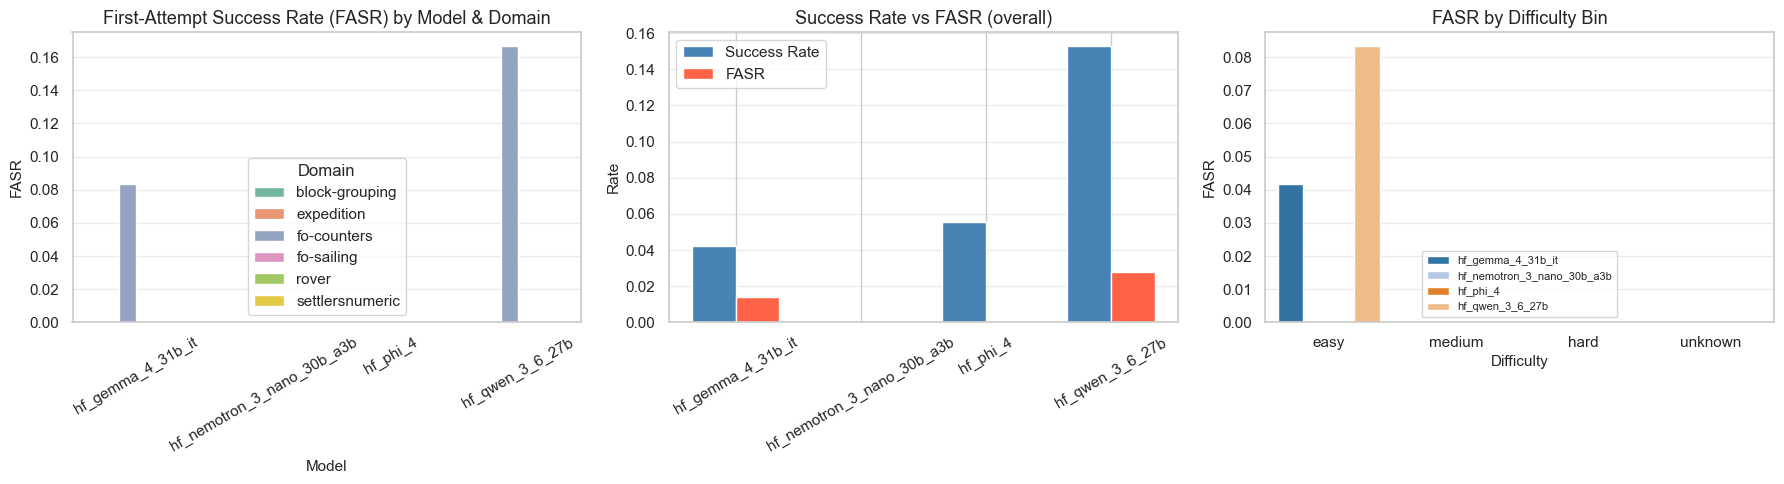

                     Model          Domain   FASR  Success_Rate
         hf_gemma_4_31b_it  block-grouping 0.0000        0.0000
         hf_gemma_4_31b_it      expedition 0.0000        0.0000
         hf_gemma_4_31b_it     fo-counters 0.0833        0.1667
         hf_gemma_4_31b_it      fo-sailing 0.0000        0.0000
         hf_gemma_4_31b_it           rover 0.0000        0.0833
         hf_gemma_4_31b_it settlersnumeric 0.0000        0.0000
hf_nemotron_3_nano_30b_a3b  block-grouping 0.0000        0.0000
hf_nemotron_3_nano_30b_a3b      expedition 0.0000        0.0000
hf_nemotron_3_nano_30b_a3b     fo-counters 0.0000        0.0000
hf_nemotron_3_nano_30b_a3b      fo-sailing 0.0000        0.0000
hf_nemotron_3_nano_30b_a3b           rover 0.0000        0.0000
hf_nemotron_3_nano_30b_a3b settlersnumeric 0.0000        0.0000
                  hf_phi_4  block-grouping 0.0000        0.0000
                  hf_phi_4      expedition 0.0000        0.0833
                  hf_phi_4     fo-counte

In [19]:
if df.empty:
    print("No data.")
else:
    df['_iter1'] = (df['Valid'] == True) & (df['Iterations'] == 1) # TRUE only when plan was valid AND produced on the first attempt. Taking the mean of this column over any group gives FASR for that group.

    # Aggregate FASR and overall SR by (Model, Domain)
    fasr_agg = df.groupby(['Model','Domain']).agg(
        FASR        = ('_iter1', 'mean'),
        Success_Rate= ('Valid',  'mean'),
    ).reset_index()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1) FASR by Model, hue=Domain
    sns.barplot(data=fasr_agg, x='Model', y='FASR', hue='Domain', ax=axes[0], palette='Set2')
    axes[0].set_title('First-Attempt Success Rate (FASR) by Model & Domain')
    axes[0].set_xlabel('Model'); axes[0].set_ylabel('FASR')
    axes[0].tick_params(axis='x', rotation=30); axes[0].grid(axis='y', alpha=.4)

    # 2) FASR vs SR comparison (per model, averaged across domains)
    model_rates = df.groupby('Model').agg(FASR=('_iter1','mean'),
                                          SR  =('Valid', 'mean')).reset_index()
    x_pos = np.arange(len(model_rates))
    w = 0.35
    axes[1].bar(x_pos - w/2, model_rates['SR'],   w, label='Success Rate', color='steelblue')
    axes[1].bar(x_pos + w/2, model_rates['FASR'], w, label='FASR',         color='tomato')
    axes[1].set_xticks(x_pos); axes[1].set_xticklabels(model_rates['Model'], rotation=30)
    axes[1].set_title('Success Rate vs FASR (overall)'); axes[1].set_ylabel('Rate')
    axes[1].legend(); axes[1].grid(axis='y', alpha=.4)

    # 3) FASR by difficulty bin (easy / medium / hard)
    fasr_diff = df.groupby(['Model','Difficulty'])['_iter1'].mean().reset_index()
    fasr_diff.columns = ['Model','Difficulty','FASR']
    diff_order = ['easy','medium','hard','unknown']
    fasr_diff['Difficulty'] = pd.Categorical(fasr_diff['Difficulty'],
                                             categories=diff_order, ordered=True)
    fasr_diff = fasr_diff.dropna(subset=['FASR'])
    if not fasr_diff.empty:
        sns.barplot(data=fasr_diff, x='Difficulty', y='FASR', hue='Model',
                    ax=axes[2], palette=MODEL_PALETTE, order=diff_order)
        axes[2].set_title('FASR by Difficulty Bin')
        axes[2].set_xlabel('Difficulty'); axes[2].set_ylabel('FASR')
        axes[2].grid(axis='y', alpha=.4); axes[2].legend(fontsize=8)

    plt.tight_layout(); plt.show()
    print(fasr_agg.round(4).to_string(index=False))

## 3B — Iteration-Weighted Success Rate (IWSR)
Penalises models that need many retries: `IWSR = mean(Valid / Iterations)` per (Model, Domain).

IWSR will always be ≥ FASR for any model-domain pair, because FASR only counts iteration-1 successes (contributing 1.0 each) while IWSR also counts later successes (contributing smaller amounts). The closer IWSR is to FASR, the more of the model's successes happened on the first attempt. The closer IWSR is to SR, the more the model converges quickly when it does succeed it does not waste iterations on problems it will eventually get right.

FASR ≤ IWSR ≤ SR This ordering is guaranteed by construction. The two gaps between them carry the meaning:
| SR–IWSR Gap | IWSR–FASR Gap | interpretation | possible conclusion |
|-------------|---------------|---------------|-----------------|
| small | small | All three nearly equal. Most successes happen on attempt 1. Retries add almost nothing. | Genuine zero-shot planning |
| small | large | IWSR≈SR but both much larger than FASR. Model rarely succeeds on attempt 1 but when it does succeed it converges quickly on attempt 2 or 3. Efficient correction capability. | Assisted planning, efficient corrector |
| large | small | FASR≈IWSR but both much smaller than SR. Most successes happen very late (attempt 4 or 5). IWSR heavily penalises these. Late retries are Stechly et al.'s random re-sampling, not correction. | Stochastic search, late luck |
| large | large | All three spread apart. SR inflated by retries, IWSR moderately inflated, FASR reveals true zero-shot capability is low. Model depends on the full iteration budget. | Fully retry-dependent |

giving another point of view on the previuos table:
- FASR ≈ IWSR ≈ SR ->almost all its success concentrated on attempt 1. The retry budget is irrelevant to it. This is the cleanest signal of genuine planning capability.
- FASR ≈ IWSR << SR ->means most successes happen very late (attempts 4 and 5). IWSR and FASR are both low because late-attempt contributions are small. SR is inflated because it ignores when the success arrived. This is the stochastic search pattern (the model is rolling dice, not planning).
- FASR << IWSR ≈ SR -> means most successes happen on attempt 2 or 3, rarely on attempt 1. IWSR captures this efficiently because the 0.5 and 0.33 contributions pull it close to SR. The model almost never gets it right first try but converges quickly when it does this is the interesting case that might indicate genuine in-context correction rather than random re-sampling, and Plot 3 can confirm whether the conditional probability rises or stays flat.

### P(valid | reached attemp k)
For each iteration k, the code filters to plans where Iterations >= k (plans that actually reached that attempt) and then computes the fraction of those that succeeded at exactly k. This is the conditional probability of success given that the run reached that attempt not the cumulative probability. It answers: of the plans still running at attempt k, how many resolved at exactly that step?

looking at plot lines some possible considerations could be done in practice:
| Line Shape |interpretation|  Consideration Reference |
|------------|---------------|-----------|
| Declining from k=1 downward | P(Valid) is highest on the first attempt and falls with each retry. The model solves its easiest problems first and harder ones take more attempts consistent with genuine difficulty-sensitive correction. | Expected for a capable reasoner |
| Flat across all k | P(Valid at k) is constant regardless of attempt number. Each retry is statistically independent the model is re-sampling, not correcting. This is the direct empirical signature of Stechly et al. (2023): feedback content is irrelevant. |Stechly, K., Marquez, M., & Kambhampati, S. (2023). GPT-4 Doesn't Know It's Wrong: An Analysis of Iterative Prompting for Reasoning Problems.Section 4, "Results" |
| Increasing from k=1 upward | P(Valid) rises with k. The model gets better with each retry. Evidence of genuine in-context learning from feedback. Very rare in practice check if feedback contains the correct answer. | Would contradict Stechly et al. |
| Low flat near zero everywhere | Model never produces valid plans at any attempt. The iteration budget is irrelevant.The model has no grounding in this domain's formal structure. Increasing the iteration budget would be a waste of computations | Valmeekam, K., Marquez, M., Sreedharan, S., & Kambhampati, S. (2023). On the Planning Abilities of Large Language Models A Critical Investigation. Advances in Neural Information Processing Systems (NeurIPS 2023).Section 5.2, "Verifier-assisted repeated backprompting of LLMs", Table 4, page 9. |


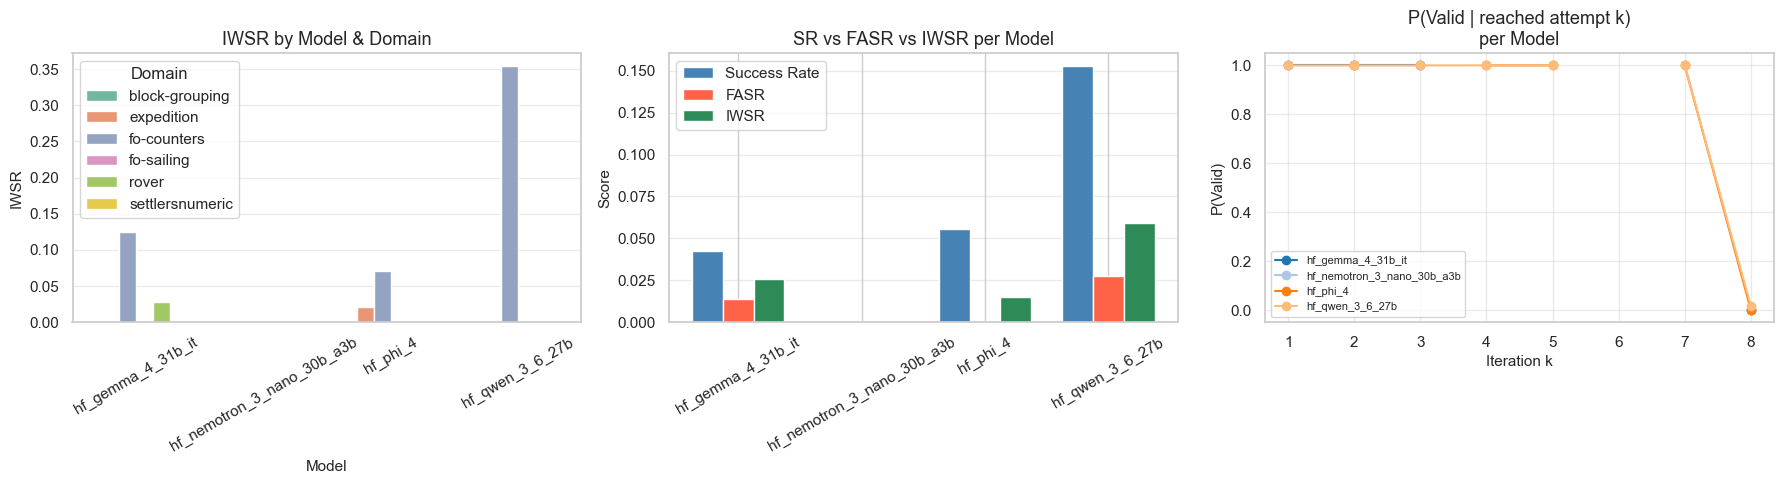

In [20]:
if df.empty:
    print("No data.")
else:
    df['_iwsr_contrib'] = df.apply(
        lambda r: (1.0 / r['Iterations']) if (r['Valid'] and pd.notna(r['Iterations']) and r['Iterations'] > 0) else 0.0,
        axis=1
    )

    iwsr_agg = df.groupby(['Model','Domain']).agg(
        IWSR        = ('_iwsr_contrib', 'mean'),
        FASR        = ('_iter1',        'mean'),
        Success_Rate= ('Valid',         'mean'),
    ).reset_index()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1) IWSR by Model, hue=Domain
    sns.barplot(data=iwsr_agg, x='Model', y='IWSR', hue='Domain', ax=axes[0], palette='Set2')
    axes[0].set_title('IWSR by Model & Domain')
    axes[0].set_xlabel('Model'); axes[0].set_ylabel('IWSR')
    axes[0].tick_params(axis='x', rotation=30); axes[0].grid(axis='y', alpha=.4)

    # 2) Triple comparison: SR vs FASR vs IWSR
    mc = df.groupby('Model').agg(SR=('Valid','mean'),
                                  FASR=('_iter1','mean'),
                                  IWSR=('_iwsr_contrib','mean')).reset_index()
    x  = np.arange(len(mc)); w = 0.25
    axes[1].bar(x - w,   mc['SR'],   w, label='Success Rate', color='steelblue')
    axes[1].bar(x,       mc['FASR'], w, label='FASR',         color='tomato')
    axes[1].bar(x + w,   mc['IWSR'], w, label='IWSR',         color='seagreen')
    axes[1].set_xticks(x); axes[1].set_xticklabels(mc['Model'], rotation=30)
    axes[1].set_title('SR vs FASR vs IWSR per Model'); axes[1].set_ylabel('Score')
    axes[1].legend(); axes[1].grid(axis='y', alpha=.4)

    # 3) Per-iteration conditional success probability: P(Valid | reached attempt k)
    max_iter = int(df['Iterations'].dropna().max()) if not df['Iterations'].dropna().empty else 0
    if max_iter > 0:
        for model, mdf in df.groupby('Model'):
            ks, probs = [], []
            for k in range(1, max_iter + 1):
                sub = mdf[mdf['Iterations'] >= k]
                if len(sub) == 0:
                    continue
                prob = sub[sub['Iterations'] == k]['Valid'].mean()
                ks.append(k); probs.append(prob)
            if ks:
                axes[2].plot(ks, probs, marker='o', label=model,
                             color=MODEL_PALETTE.get(model, 'gray'))
        axes[2].set_title('P(Valid | reached attempt k)\nper Model')
        axes[2].set_xlabel('Iteration k'); axes[2].set_ylabel('P(Valid)')
        axes[2].legend(fontsize=8); axes[2].grid(alpha=.4)

    plt.tight_layout(); plt.show()

## 3C — Retry Gap Analysis
`retry_gap = Success_Rate − FASR`. Large gaps indicate dependence on iterative repair.

SR - FASR per model , averaged across all domains. measurment of non zero-shot success rate.
- if 0.0 all successes happened on the first attempt , retries contributed nothing
- if 0.5 half of the successes were dependent on the retry mechanism available.

### Diverging bar chart of RG

The code assigns colour per bar: 'tomato' if v > 0 else 'steelblue'. In practice almost all bars will be red (positive gap) because SR ≥ FASR by definition (retries can only add to SR, never subtract). A blue bar would mean SR < FASR, which would be a data anomaly.

the models that are more independent by the iteration scaffold are the ones at the top ( for which the RG has the lowest value ).

### FASR vs IWSR scatter with SR Encoding

how to read the three encoding dimensions simultaneusly:
- X position (FASR): how far right a dot sits tells you the model's zero-shot capability ( how often it gets the answer right without any retry ).

- Y position (IWSR): how high a dot sits tells you how efficiently the model uses retries when it does need them ( early convergence scores high, late lucky successes score low ).

- Dot size and colour (SR): large green dots have high overall success rate. Small red dots have low overall success rate.

- diagonal reference line (FASR = IWSR):
    - Points exactly on the diagonal have IWSR = FASR, meaning every success happened on the first attempt (no value came from any retry).
    - Points above the diagonal have IWSR > FASR, meaning retries contributed some value (late successes pulled IWSR above the FASR floor). The further above the diagonal, the more the model depends on retries.
    - No point can fall below the diagonal because IWSR ≥ FASR by mathematical construction.

    

| Position in Scatter | Dot Character | Interpretation |
|---------------------|---------------|----------------|
| Top-right, on/near diagonal | Large green, near diagonal | Genuine planner. High FASR, IWSR close to FASR, high SR. Most success is first-attempt. Best case.|
| Top-left, well above diagonal | Medium yellow, high above diagonal | Efficient corrector. Low FASR but IWSR pulled up by early-retry successes. Model rarely gets it right first but corrects quickly when it fails.|
| Bottom-right, below mid | Large dot, low position | Inconsistent. High FASR but low IWSR ( paradoxical, check data. Should not occur by construction ).|
| Bottom-left | Small red, bottom-left | No capability. Both FASR and IWSR near zero. Small dot confirms low SR too. Iteration budget irrelevant.|
| Top-left, large dot | Large green or yellow, high IWSR, low FASR | Dangerous case. High SR and high IWSR suggest good performance but low FASR reveals retry dependency. SR is misleading without FASR context.|

#### Dots ColorMap-Size significate
- SR = 0.0  →  deep red-little dot    (model never produces valid plans)
- SR = 0.25 →  orange-red
- SR = 0.50 →  yellow-half dimension dot      (model succeeds half the time)
- SR = 0.75 →  yellow-green
- SR = 1.0  →  deep green-large dot   (model always produces valid plans)

the intermediate values are represented in a gradient of color-dimension going from 0 to 1.

e.g. A large dot far to the bottom-left means high SR but low FASR and IWSR the model's success is almost entirely retry-dependent.



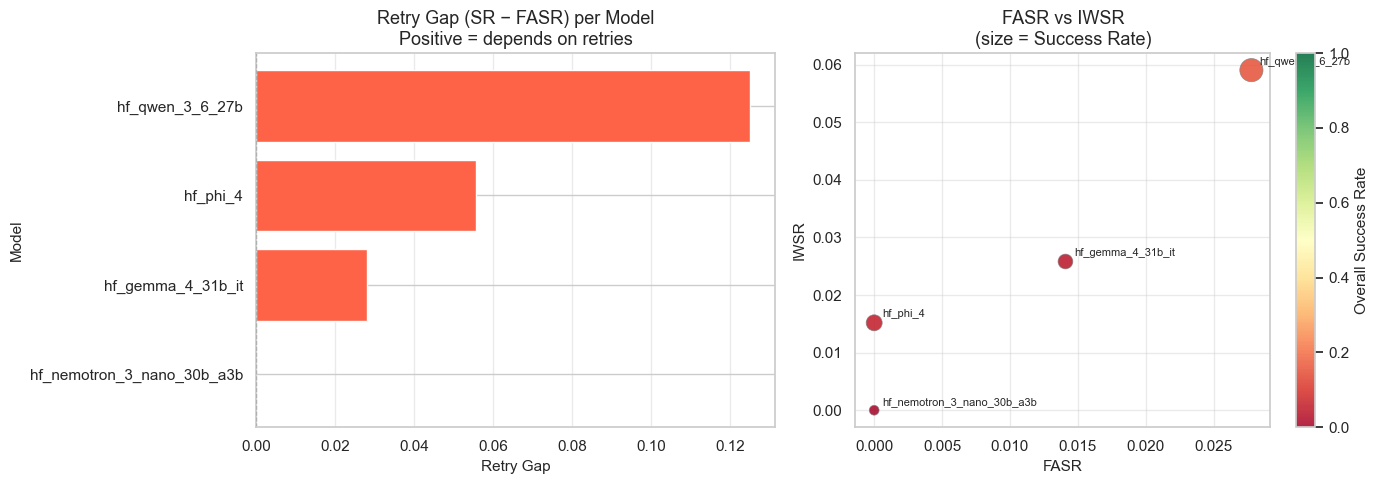

                     Model     SR   FASR   IWSR  retry_gap
hf_nemotron_3_nano_30b_a3b 0.0000 0.0000 0.0000     0.0000
         hf_gemma_4_31b_it 0.0423 0.0141 0.0258     0.0282
                  hf_phi_4 0.0556 0.0000 0.0152     0.0556
           hf_qwen_3_6_27b 0.1528 0.0278 0.0590     0.1250


In [21]:
if df.empty:
    print("No data.")
else:
    rg = df.groupby('Model').agg(
        SR  = ('Valid',          'mean'),
        FASR= ('_iter1',         'mean'),
        IWSR= ('_iwsr_contrib',  'mean'),
    ).reset_index()
    rg['retry_gap'] = rg['SR'] - rg['FASR']
    rg = rg.sort_values('retry_gap', ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1) Diverging bar chart: models sorted by retry_gap
    colors = ['tomato' if v > 0 else 'steelblue' for v in rg['retry_gap']]
    axes[0].barh(rg['Model'], rg['retry_gap'], color=colors, edgecolor='white')
    axes[0].axvline(0, color='black', linewidth=.8, linestyle='--')
    axes[0].set_title('Retry Gap (SR − FASR) per Model\n'
                       'Positive = depends on retries')
    axes[0].set_xlabel('Retry Gap'); axes[0].set_ylabel('Model')
    axes[0].grid(axis='x', alpha=.4)

    # 2) Scatter: FASR (x) vs IWSR (y), size=SR, color=Domain-average SR
    # aggregate per model across all domains
    sc_data = df.groupby('Model').agg(
        FASR= ('_iter1',        'mean'),
        IWSR= ('_iwsr_contrib', 'mean'),
        SR  = ('Valid',         'mean'),
    ).reset_index()
    sc = axes[1].scatter(sc_data['FASR'], sc_data['IWSR'],
                          s=sc_data['SR'] * 1500 + 50,
                          c=sc_data['SR'], cmap='RdYlGn', vmin=0, vmax=1,
                          edgecolors='gray', linewidths=.5, alpha=.85)
    for _, r in sc_data.iterrows():
        axes[1].annotate(r['Model'], (r['FASR'], r['IWSR']),
                          textcoords='offset points', xytext=(6, 4), fontsize=8)
    plt.colorbar(sc, ax=axes[1], label='Overall Success Rate')
    axes[1].set_title('FASR vs IWSR\n(size = Success Rate)')
    axes[1].set_xlabel('FASR'); axes[1].set_ylabel('IWSR')
    axes[1].grid(alpha=.4)

    plt.tight_layout(); plt.show()
    print(rg[['Model','SR','FASR','IWSR','retry_gap']].round(4).to_string(index=False))

---
# Section 4 — Cross-Domain and Cross-Model Comparative Analysis

## 4A — Within-Domain Model Ranking
Rank models on each metric within each domain.

### HeatMap
Three reading directions

- Read a row (one model): scan left to right across all metrics. A row that is uniformly green means the model leads on every dimension in this domain. A row that is uniformly red means it is worst on everything. A mixed row reveals a capability profile (green on some metrics, red on others — showing strengths and weaknesses simultaneously) .

- Read a column (one metric): scan top to bottom. This tells you which model dominates on a specific metric. A column that is all the same colour means this metric provides no discriminating information in this domain (all models perform similarly).

- Read patterns across cells: look for blocks of green or red. A model with green SR and FASR but red halluc and CoT is succeeding despite poor domain grounding (likely pattern-matching) . A model with red SR but green exec_ratio and PAS is failing at the plan level but demonstrating domain understanding at the process level.

### Metric pair to always Read toghether

certain metrics should be always be read toghether never in isolation . the scientific and consideration meaning comes from the combination of these toghether

####  CAPABILITY TRIANGLE : SR + FASR + IWSR + RG -> (is performance genuine or scaffolded by the retry mechanism?)
> **RG = SR − FASR** (raw absolute gap, not normalised).

> Read SR and FASR first to establish the outcome and zero-shot baseline.

> Then use RG to quantify retry dependency before checking IWSR position for efficiency.

| SR | FASR | RG = SR − FASR | IWSR position | Diagnosis | Reference |
|---|---|---|---|---|---|
| **High** | **High** | **≈ 0.0–0.10** | ≈ FASR (on or near diagonal) | Genuine zero-shot planner. Nearly all success is first-attempt. Retries add nothing. RG confirms the retry mechanism is irrelevant. | Strongest claim  |
| **High** | **Medium** | **0.10–0.25** | Close to SR (well above FASR) | Efficient corrector. First-attempt rate is moderate but the model converges quickly on early retries (attempts 2–3). RG is moderate but IWSR recovers most of SR, meaning the correction is efficient rather than lucky. | Assisted planning |
| **High** | **Low** | **> 0.30** | Far below SR, close to FASR | Stochastic search. SR is heavily inflated by the retry mechanism. RG > 0.30 is the primary discriminator: most reported success disappears when retries are removed. IWSR close to FASR confirms that late retries (attempts 4–5) are responsible — each attempt is an independent re-sample, not a correction. | Stechly et al. (2023) |
| **Medium** | **Low** | **0.20–0.40** | Between SR and FASR, closer to FASR | Partial capability, retry-dependent for the successful fraction. RG confirms that the modest SR is substantially scaffolded. IWSR position between SR and FASR indicates some early-retry contribution but predominantly late-retry luck. | Stechly et al. (2023) |
| **Low** | **Low** | **≈ 0.0–0.05** | ≈ FASR (both near 0) | No planning capability at any iteration. RG near zero does not indicate capability — it reflects that there is nothing for retries to inflate. The iteration budget is irrelevant. Check halluc\_rate: if high, the model is not reading the domain schema at all. | Valmeekam et al. (2023) |

---

## How to use RG as the intermediate discrimination step

```
1. Read SR  → establishes the outcome ceiling
2. Read FASR → establishes genuine zero-shot capability
3. Compute RG = SR − FASR
       RG < 0.10  → retry-independent  → read IWSR to confirm efficiency
       RG 0.10–0.30 → moderate dependency → read IWSR to classify corrector vs searcher
       RG > 0.30  → strong dependency   → Stechly et al. prediction: stochastic search
                                           verify with P(Valid | k) profile (flat = confirmed)
4. Read IWSR position relative to SR and FASR
       IWSR ≈ SR    → successes concentrated on attempts 2–3 (efficient corrector)
       IWSR ≈ FASR  → successes concentrated on attempt 1 (genuine) or attempt 4–5 (stochastic)
                      → RG discriminates which case: low RG = genuine, high RG = stochastic
```

---

## Notes on edge cases

| Edge case | RG value | Correct reading |
|---|---|---|
| SR = 0, FASR = 0 | RG = 0.0 | Zero RG does **not** mean genuine planner. Check SR first if SR is near zero, RG = 0 means nothing succeeded regardless of retries. |
| SR high, FASR high, RG small but non-zero | RG ≈ 0.05–0.08 | Effectively retry-independent. A small non-zero RG is expected from statistical variation across problems, not genuine retry contribution. |
| RG slightly negative | RG < 0 | Data anomaly FASR cannot exceed SR by construction. Check for NaN handling or groupby filtering issues in the computation. |

####  FAILURE ANATOMY : ER + PAS -> (how far the plan runs/depth? why it stopped/ the failure type?)

those two metrics are mostly useful when considering a SR < 0.15  in order to determine the failure anatomy

| exec_ratio | PAS | What the LLM is Doing | Valmeekam et al. Phase |
|------------|-----|-----------------------|------------------------|
| High >0.70 | High >0.70 | Runs deep, ordering errors only near goal. Understands domain, mis-sequences near the end. | Phase 2 failure long horizon sequencing failure |
| High >0.70 | Low <0.30 | Runs deep but fabricates states throughout. Knows vocabulary, invents world transitions. | Phase 1/2 boundary vocabulary OK, world model broken |
| Low <0.30 | High >0.70 | Fails early but failures are ordering errors on the few non-hallucinated steps. Rare pattern. | Phase 2 with vocabulary issues |
| Low <0.30 | Low <0.30 | Fails immediately. Invents states from step 1. Domain not comprehended. | Phase 1 failure vocabulary |
| Medium | NaN | Some plans run far, others fail immediately. PAS undefined (all valid or all hallucinated). Check halluc first. And also check Temporal distance value in order to determine if we are in phase 1 or phase2 failure| Mixed — check halluc gate |

#### REASONING TEST : SR + CoT -> (Are the successes genuine or reflect approximate/stochastic retrivial?)

#### REFINEMENT PAIR : IHR + PAS -> (which kind of failure happened?)






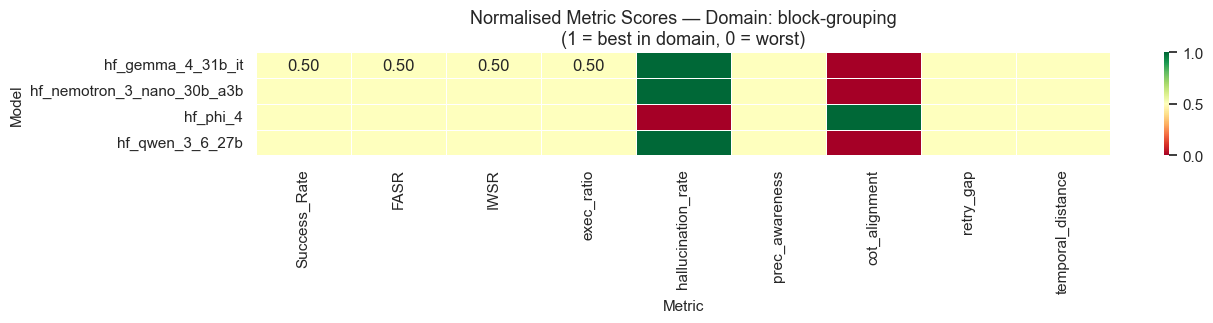

<Figure size 640x480 with 0 Axes>


Rank table for domain 'block-grouping' (1=best):
                            Success_Rate  FASR  IWSR  exec_ratio  hallucination_rate  prec_awareness  cot_alignment  retry_gap  temporal_distance
Model                                                                                                                                            
hf_gemma_4_31b_it                    1.0   1.0   1.0         1.0                 1.0             1.0            2.0        1.0                1.0
hf_nemotron_3_nano_30b_a3b           1.0   1.0   1.0         1.0                 1.0             1.0            2.0        1.0                1.0
hf_phi_4                             1.0   1.0   1.0         1.0                 4.0             1.0            1.0        1.0                1.0
hf_qwen_3_6_27b                      1.0   1.0   1.0         1.0                 1.0             1.0            2.0        1.0                1.0

Temporal distance diagnostic — Domain: 'block-grouping'
                 

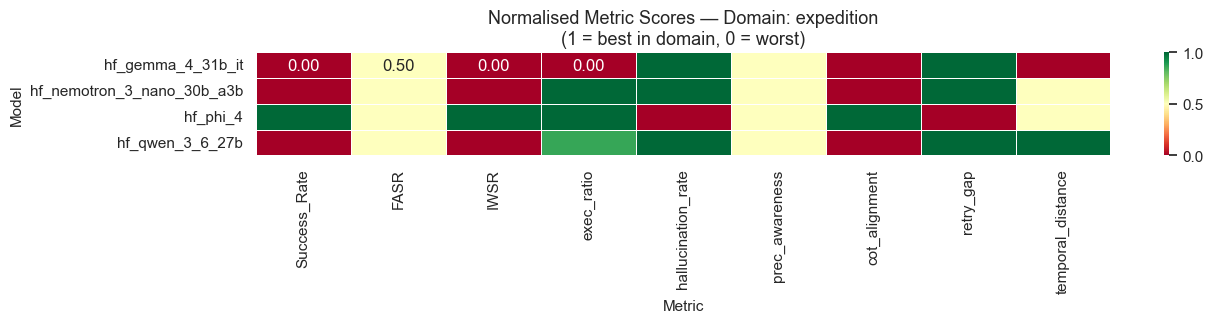

<Figure size 640x480 with 0 Axes>


Rank table for domain 'expedition' (1=best):
                            Success_Rate  FASR  IWSR  exec_ratio  hallucination_rate  prec_awareness  cot_alignment  retry_gap  temporal_distance
Model                                                                                                                                            
hf_gemma_4_31b_it                    2.0   1.0   2.0         4.0                 1.0             1.0            2.0        1.0                2.0
hf_nemotron_3_nano_30b_a3b           2.0   1.0   2.0         1.0                 1.0             3.0            2.0        1.0                3.0
hf_phi_4                             1.0   1.0   1.0         1.0                 4.0             3.0            1.0        4.0                3.0
hf_qwen_3_6_27b                      2.0   1.0   2.0         3.0                 1.0             1.0            2.0        1.0                1.0

Temporal distance diagnostic — Domain: 'expedition'
                         

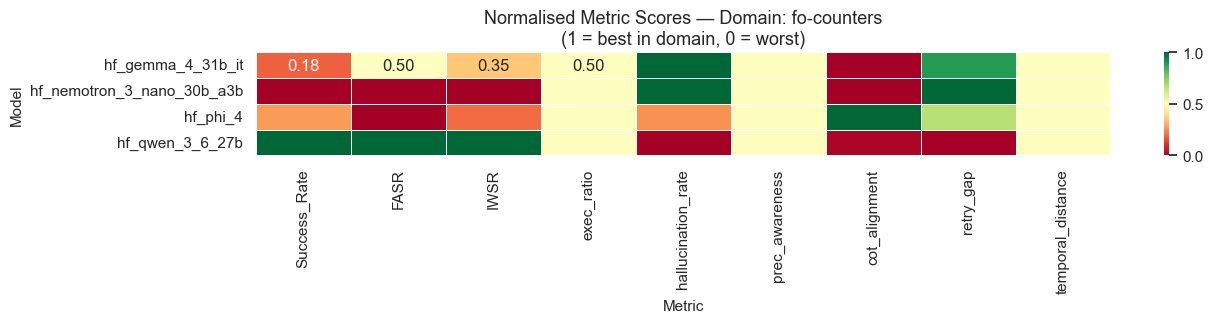

<Figure size 640x480 with 0 Axes>


Rank table for domain 'fo-counters' (1=best):
                            Success_Rate  FASR  IWSR  exec_ratio  hallucination_rate  prec_awareness  cot_alignment  retry_gap  temporal_distance
Model                                                                                                                                            
hf_gemma_4_31b_it                    3.0   2.0   2.0         1.0                 1.0             1.0            3.0        2.0                1.0
hf_nemotron_3_nano_30b_a3b           4.0   3.0   4.0         1.0                 1.0             1.0            3.0        1.0                1.0
hf_phi_4                             2.0   3.0   3.0         1.0                 3.0             1.0            1.0        3.0                1.0
hf_qwen_3_6_27b                      1.0   1.0   1.0         1.0                 4.0             1.0            2.0        4.0                1.0

Temporal distance diagnostic — Domain: 'fo-counters'
                       

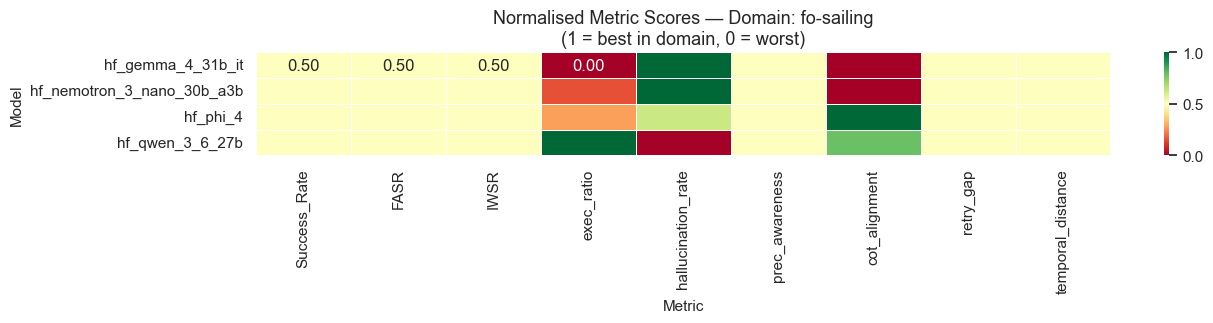

<Figure size 640x480 with 0 Axes>


Rank table for domain 'fo-sailing' (1=best):
                            Success_Rate  FASR  IWSR  exec_ratio  hallucination_rate  prec_awareness  cot_alignment  retry_gap  temporal_distance
Model                                                                                                                                            
hf_gemma_4_31b_it                    1.0   1.0   1.0         4.0                 1.0             1.0            3.0        1.0                1.0
hf_nemotron_3_nano_30b_a3b           1.0   1.0   1.0         3.0                 1.0             1.0            3.0        1.0                1.0
hf_phi_4                             1.0   1.0   1.0         2.0                 3.0             1.0            1.0        1.0                1.0
hf_qwen_3_6_27b                      1.0   1.0   1.0         1.0                 4.0             1.0            2.0        1.0                1.0

Temporal distance diagnostic — Domain: 'fo-sailing'
                         

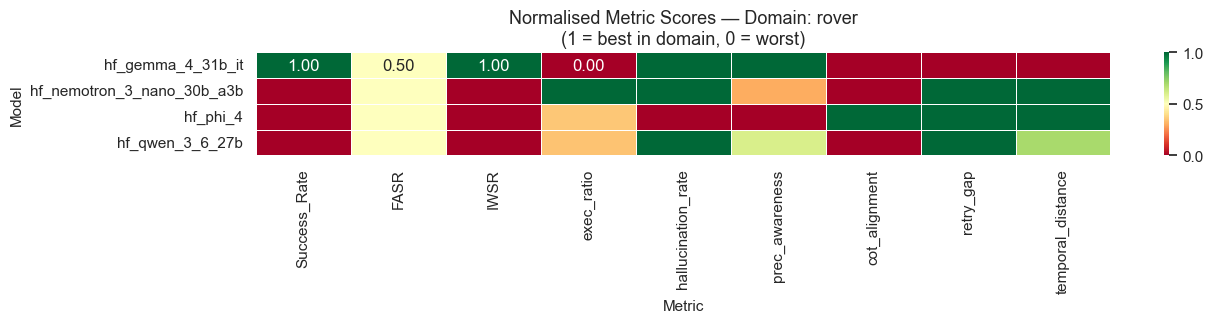

<Figure size 640x480 with 0 Axes>


Rank table for domain 'rover' (1=best):
                            Success_Rate  FASR  IWSR  exec_ratio  hallucination_rate  prec_awareness  cot_alignment  retry_gap  temporal_distance
Model                                                                                                                                            
hf_gemma_4_31b_it                    1.0   1.0   1.0         4.0                 1.0             1.0            2.0        4.0                4.0
hf_nemotron_3_nano_30b_a3b           2.0   1.0   2.0         1.0                 1.0             3.0            2.0        1.0                1.0
hf_phi_4                             2.0   1.0   2.0         2.0                 4.0             4.0            1.0        1.0                1.0
hf_qwen_3_6_27b                      2.0   1.0   2.0         3.0                 1.0             2.0            2.0        1.0                3.0

Temporal distance diagnostic — Domain: 'rover'
                            Success

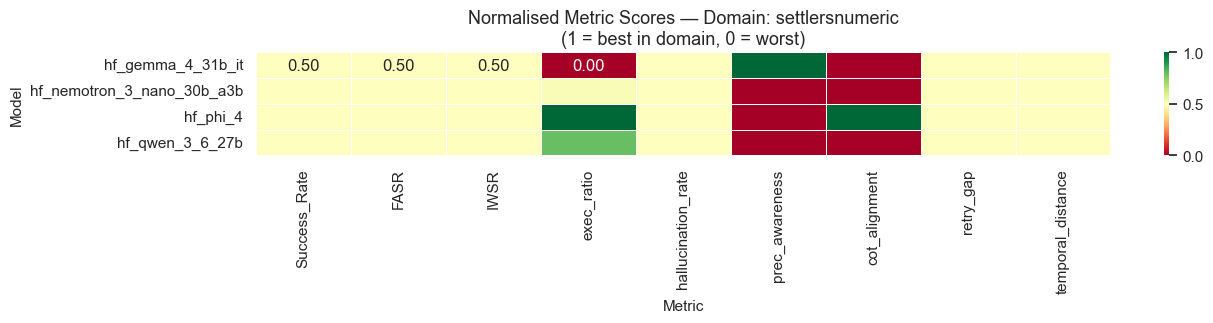

<Figure size 640x480 with 0 Axes>


Rank table for domain 'settlersnumeric' (1=best):
                            Success_Rate  FASR  IWSR  exec_ratio  hallucination_rate  prec_awareness  cot_alignment  retry_gap  temporal_distance
Model                                                                                                                                            
hf_gemma_4_31b_it                    1.0   1.0   1.0         4.0                 1.0             1.0            2.0        1.0                1.0
hf_nemotron_3_nano_30b_a3b           1.0   1.0   1.0         3.0                 1.0             2.0            2.0        1.0                2.0
hf_phi_4                             1.0   1.0   1.0         1.0                 1.0             2.0            1.0        1.0                2.0
hf_qwen_3_6_27b                      1.0   1.0   1.0         2.0                 1.0             2.0            2.0        1.0                2.0

Temporal distance diagnostic — Domain: 'settlersnumeric'
               

In [22]:
if df.empty:
    print("No data.")
else:
    # aggregation of all metrics into one dataframe for the heatmap and ranking table, this is done per Model and Domain pair.
    # ── METRIC REGISTRY ──────────────────────────────────────────────────────
    # 'max' = higher is better (e.g. success rate)
    # 'min' = lower is better (e.g. hallucination, retry dependency, ordering error distance)
    # All metrics are normalised to [0,1] within each domain before display.
    # 'min' metrics are inverted after normalisation so that green always means good.
    RANK_METRICS = {
        'Success_Rate'    : 'max',  # higher is better
        'FASR'            : 'max',
        'IWSR'            : 'max',
        'exec_ratio'      : 'max',
        'hallucination_rate': 'min',   # lower is better 
        'prec_awareness'  : 'max',
        'cot_alignment'   : 'max',
        'retry_gap'         : 'min',  # SR - FASR: lower = less retry dependency = better
        'temporal_distance' : 'min',  # mean steps between failure and last valid precondition
                                      # lower = near-miss ordering error = more fixable
    }

    # Build aggregated metric table (Model, Domain) → scalar values
    per_dom = df.groupby(['Model','Domain']).agg(
        Success_Rate   = ('Valid',                    'mean'),
        exec_ratio     = ('executability_ratio',      'mean'),
        hallucination_rate = ('hallucination_rate',   'mean'),
        prec_awareness = ('precondition_awareness_score', lambda x: x.dropna().mean()),
        cot_alignment  = ('cot_alignment_score',      lambda x: x.dropna().mean()),
        #aggregate temporal_distance (mean over plans that have sequencing errors).
        # NaN for a model means either all plans were valid (no failures to classify)
        # or all failures were state fabrications (PAS=0, so no sequencing errors exist).
        # The two cases are discriminated later using SR.
        temporal_distance  = ('mean_temporal_distance',       lambda x: x.dropna().mean()),
    ).reset_index()

    # Merge in FASR & IWSR
    per_dom = per_dom.merge(
        df.groupby(['Model','Domain']).agg(
            FASR=('_iter1',       'mean'),
            IWSR=('_iwsr_contrib','mean'),
        ).reset_index(),
        on=['Model','Domain'], how='left'
    )
    # Compute retry_gap = SR - FASR.
    # Measures how much of the model's success rate disappears when retries are removed.
    # Must be computed after FASR is available from the merge above.
    # retry_gap = 0.0 means every success was on attempt 1 (retry-independent).
    # retry_gap = 0.5 means half the success rate depends on the retry mechanism.
    per_dom['retry_gap'] = per_dom['Success_Rate'] - per_dom['FASR']

    metric_cols = list(RANK_METRICS.keys())

    # PER DOMAIN HEATMAP TABLE AND RANKING
    for dom in sorted(per_dom['Domain'].unique()):
        sub = per_dom[per_dom['Domain'] == dom].copy().set_index('Model')
        sub = sub[metric_cols]

        # Normalise to [0,1] within this domain 
        # Values are relative to the best model in this domain for each metric.
        # This means 1.0 = best in domain, 0.0 = worst in domain.
        # Scores are NOT comparable across domains.
        normed = sub.copy()
        for col, direction in RANK_METRICS.items():
            if col not in normed.columns:
                normed[col] = float('nan')
                continue
            
            cmin, cmax = normed[col].min(), normed[col].max()
            if cmax > cmin:
                normed[col] = (normed[col] - cmin) / (cmax - cmin)
                if direction == 'min':
                    # Invert so that green always means good regardless of metric direction.
                    # hallucination_rate=0.0 → normalised 1.0 (deep green).
                    # retry_gap=0.0       → normalised 1.0 (deep green).
                    # temporal_distance low → normalised close to 1.0 (green).
                    normed[col] = 1 - normed[col]
            else:
                # handle the edge case where all models have the same score for a metric in a domain, in this case we set the normalized score to 0.5 for all models, indicating that they are tied in the middle of the scale. 
                # This prevents division by zero and also visually indicates that there is no difference between the models for this metric in this domain.
                normed[col] = 0.5

        # temporal_distance is NaN in two legitimate situations with opposite meanings:
        #   (A) SR > 0.70 and NaN: model has so few failures that no sequencing errors
        #       were recorded. This is the best case (do NOT penalise with red).
        #       Fill with 1.0 (deep green) to reflect that no ordering errors occurred.
        #   (B) SR ≤ 0.70 and NaN: model has failures but temporal_distance is still NaN,
        #       meaning all failures are state fabrications (PAS≈0, no sequencing errors).
        #       This is not good but temporal_distance is genuinely inapplicable here.
        #       Fill with 0.5 (neutral yellow) the red signal comes from PAS and exec,
        #       not from temporal_distance.
        if 'temporal_distance' in normed.columns:
            for model_idx in normed.index:
                if pd.isna(normed.loc[model_idx, 'temporal_distance']):
                    sr_val = sub.loc[model_idx, 'Success_Rate'] \
                             if 'Success_Rate' in sub.columns else float('nan')
                    if pd.notna(sr_val) and sr_val > 0.70:
                        normed.loc[model_idx, 'temporal_distance'] = 1.0  # no failures = best
                    else:
                        normed.loc[model_idx, 'temporal_distance'] = 0.5  # fabrications = N/A


        # Heatmap
        fig, ax = plt.subplots(figsize=(max(10, len(metric_cols)*1.5), max(3, len(sub)*0.6+1)))
        sns.heatmap(normed.fillna(0).astype(float), ax=ax, annot=True, fmt='.2f',
                    cmap='RdYlGn', vmin=0, vmax=1, linewidths=.5)
        ax.set_title(f'Normalised Metric Scores — Domain: {dom}\n'
                     f'(1 = best in domain, 0 = worst)')
        ax.set_xlabel('Metric'); ax.set_ylabel('Model')
        plt.tight_layout(); plt.show()

        # overlay the raw retry_gap value as a small italic annotation
        # on the retry_gap column cells. This shows the absolute gap (Δ = SR - FASR)
        # alongside the normalised relative score, since the normalised score alone
        # cannot reveal whether a domain-wide retry dependency exists
        # (all models would score 0.5 even if all have a gap of 0.45).
        if 'retry_gap' in normed.columns:
            col_pos = list(normed.columns).index('retry_gap')
            for i, model_idx in enumerate(normed.index):
                raw_gap = sub.loc[model_idx, 'retry_gap']
                if pd.notna(raw_gap):
                    ax.text(
                        col_pos + 0.5,       # centre of the cell horizontally
                        i + 0.78,            # below the main annotation
                        f'Δ{raw_gap:.2f}',
                        ha='center', va='center',
                        fontsize=7, color='navy', style='italic'
                    )
 
        # overlay the raw temporal_distance value on the temporal_distance column.
        # This shows the actual mean step distance (in plan steps) between the failure
        # and the last step where the violated precondition was true.
        # Interpretation:
        #   1-2  = near-miss ordering, most fixable
        #   3-5  = moderate sequencing breakdown
        #   >5   = severely broken causal ordering
        if 'temporal_distance' in normed.columns:
            td_col_pos = list(normed.columns).index('temporal_distance')
            for i, model_idx in enumerate(normed.index):
                raw_td = sub.loc[model_idx, 'temporal_distance']
                if pd.notna(raw_td):
                    ax.text(
                        td_col_pos + 0.5,
                        i + 0.78,
                        f'{raw_td:.1f}s',   # 's' = steps
                        ha='center', va='center',
                        fontsize=7, color='darkred', style='italic'
                    )
 
        ax.set_title(
            f'Normalised Metric Scores — Domain: {dom}\n'
            f'(1 = best in domain, 0 = worst)  |  '
            f'retry_gap: Δ=raw SR-FASR (navy italic)  |  '
            f'temporal_distance: raw steps shown (red italic); '
            f'NaN→1.0 if SR>0.70 else →0.5'
        )
        ax.set_xlabel('Metric')
        ax.set_ylabel('Model')
        plt.tight_layout()
        plt.show()
 
        # Rank table
        # For 'max' metrics: rank descending (highest raw value = rank 1).
        # For 'min' metrics: rank ascending (lowest raw value = rank 1).
        # method='min': tied models share the better rank; the next rank is skipped.
        # This prevents artificially separating tied models.
        rank_tbl = pd.DataFrame(index=sub.index)
        for col, direction in RANK_METRICS.items():
            if col not in sub.columns:
                rank_tbl[col] = float('nan')
                continue
            if direction == 'max':
                rank_tbl[col] = sub[col].rank(
                    ascending=False, method='min', na_option='bottom'
                )
            else:  # 'min' — lower raw value is better → rank ascending
                rank_tbl[col] = sub[col].rank(
                    ascending=True, method='min', na_option='bottom'
                )
 
        print(f"\nRank table for domain '{dom}' (1=best):")
        print(rank_tbl.round(0).fillna('-').to_string())
 
        # Temporal distance diagnostic
        # Printed separately because it is most informative when cross-read
        # with exec_ratio and prec_awareness. Only meaningful when
        # exec_ratio is in the 0.30-0.80 range and SR < 0.15.
        print(f"\nTemporal distance diagnostic — Domain: '{dom}'")
        td_diag = per_dom[per_dom['Domain'] == dom][[
            'Model', 'Success_Rate', 'exec_ratio',
            'prec_awareness', 'temporal_distance', 'retry_gap'
        ]].set_index('Model').round(3)
        print(td_diag.to_string())
        print(
            "\n  Temporal distance reading guide:\n"
            "  NaN + SR > 0.70  → no failures; metric not applicable (best case)\n"
            "  NaN + SR ≤ 0.70  → all failures are state fabrications; no sequencing errors\n"
            "  1-2  steps       → near-miss ordering error; action placed 1-2 steps too late\n"
            "  3-5  steps       → moderate sequencing breakdown\n"
            "  > 5  steps       → severely broken causal ordering\n"
            "  (Most informative when exec_ratio 0.30-0.80 and prec_awareness > 0.30)\n"
        )

## 4B — Cross-Domain Consistency
Models with low rank variance are *generalist planners*; high variance indicates domain specialisation.

C:\Users\simo2\AppData\Local\Temp\ipykernel_2440\883578929.py:33: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = spearmanr(sr_pivot[c1], sr_pivot[c2])


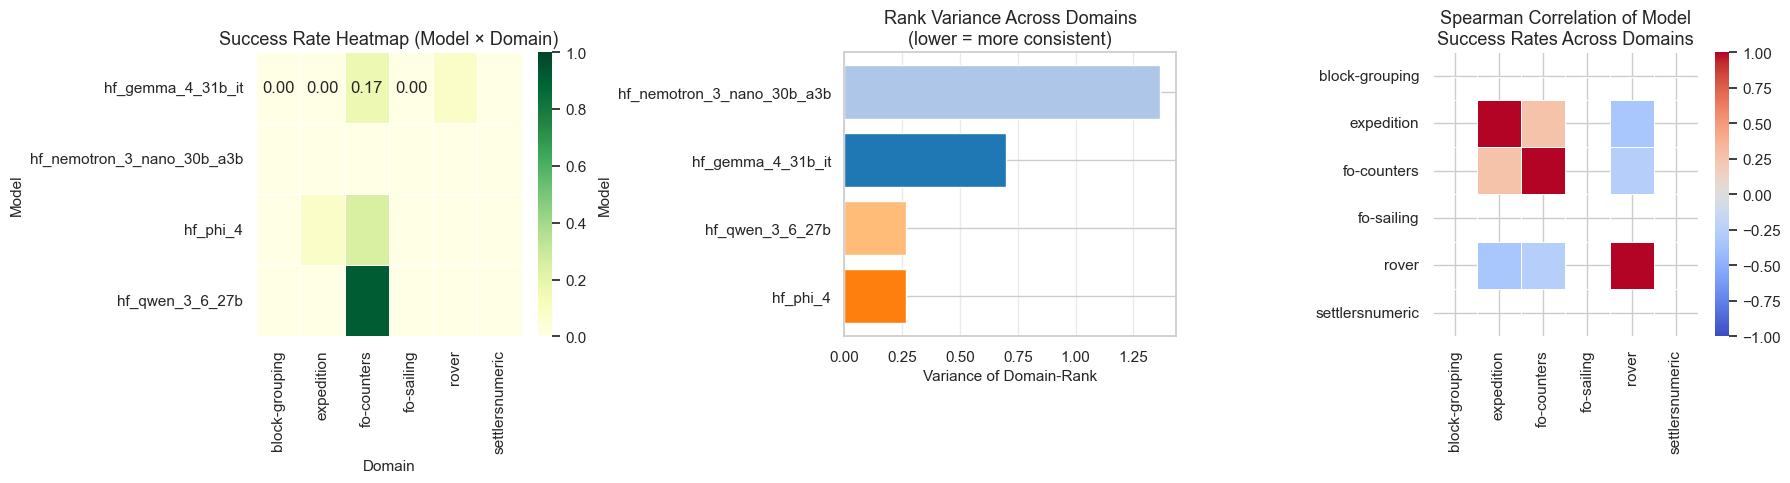

In [23]:
if df.empty:
    print("No data.")
else:
    sr_pivot = df.groupby(['Model','Domain'])['Valid'].mean().unstack('Domain').fillna(0)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1) Heatmap: Model × Domain success rate (annotated)
    sns.heatmap(sr_pivot, ax=axes[0], annot=True, fmt='.2f', cmap='YlGn',
                linewidths=.4, vmin=0, vmax=1)
    axes[0].set_title('Success Rate Heatmap (Model × Domain)')
    axes[0].set_xlabel('Domain'); axes[0].set_ylabel('Model')

    # 2) Rank variance per model
    sr_ranks = sr_pivot.rank(ascending=False, method='min')
    rank_var = sr_ranks.var(axis=1).reset_index()
    rank_var.columns = ['Model', 'rank_variance']
    rank_var = rank_var.sort_values('rank_variance')
    axes[1].barh(rank_var['Model'], rank_var['rank_variance'],
                 color=[MODEL_PALETTE.get(m, 'steelblue') for m in rank_var['Model']],
                 edgecolor='white')
    axes[1].set_title('Rank Variance Across Domains\n(lower = more consistent)')
    axes[1].set_xlabel('Variance of Domain-Rank'); axes[1].set_ylabel('Model')
    axes[1].grid(axis='x', alpha=.4)

    # 3) Spearman correlation between domains
    if sr_pivot.shape[1] >= 2:
        if HAS_SCIPY:
            cols = sr_pivot.columns.tolist()
            corr_mat = np.zeros((len(cols), len(cols)))
            for i, c1 in enumerate(cols):
                for j, c2 in enumerate(cols):
                    r, _ = spearmanr(sr_pivot[c1], sr_pivot[c2])
                    corr_mat[i, j] = r
            corr_df = pd.DataFrame(corr_mat, index=cols, columns=cols)
        else:
            corr_df = sr_pivot.corr(method='spearman')

        sns.heatmap(corr_df, ax=axes[2], annot=True, fmt='.2f',
                    cmap='coolwarm', vmin=-1, vmax=1, linewidths=.4)
        axes[2].set_title('Spearman Correlation of Model\nSuccess Rates Across Domains')

    plt.tight_layout(); plt.show()

## 4C — Failure Mode Taxonomy Plot
Key interpretive plot: each model is positioned by *how* it fails.

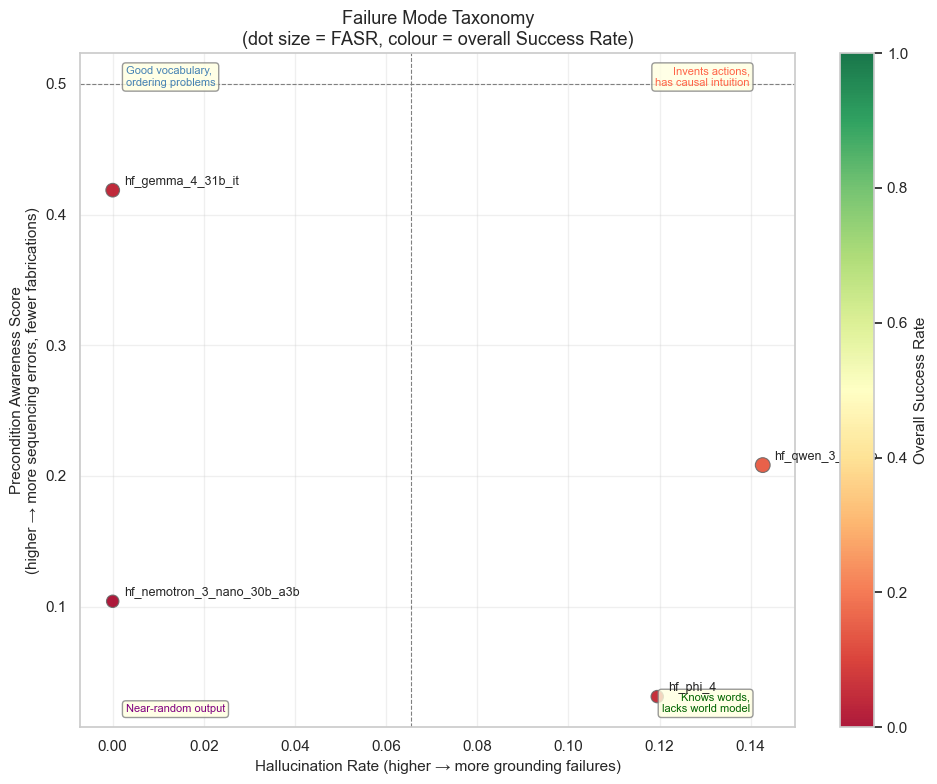

In [24]:
if df.empty:
    print("No data.")
else:
    tax = df.groupby('Model').agg(
        halluc_rate  = ('hallucination_rate',          'mean'),
        pas          = ('precondition_awareness_score', lambda x: x.dropna().mean()),
        fasr         = ('_iter1',                      'mean'),
        sr           = ('Valid',                       'mean'),
    ).reset_index().fillna({'pas': 0.5})  # default PAS when no failures

    fig, ax = plt.subplots(figsize=(10, 8))

    sc = ax.scatter(
        tax['halluc_rate'], tax['pas'],
        s   = tax['fasr'] * 1200 + 80,
        c   = tax['sr'],
        cmap='RdYlGn', vmin=0, vmax=1,
        edgecolors='dimgray', linewidths=.8, alpha=.9, zorder=3
    )
    plt.colorbar(sc, ax=ax, label='Overall Success Rate')

    for _, r in tax.iterrows():
        ax.annotate(r['Model'], (r['halluc_rate'], r['pas']),
                    textcoords='offset points', xytext=(8, 4), fontsize=9, zorder=4)

    # Quadrant lines at midpoints
    xm = tax['halluc_rate'].mean() if len(tax) else 0.5
    ym = 0.5
    ax.axvline(xm, color='gray', linestyle='--', linewidth=.8, zorder=1)
    ax.axhline(ym, color='gray', linestyle='--', linewidth=.8, zorder=1)

    # Quadrant labels
    xl, xr = ax.get_xlim(); yb, yt = ax.get_ylim()
    pad = 0.01
    ax.text(xl + pad, yt - pad, 'Good vocabulary,\nordering problems',
            ha='left', va='top', fontsize=8, color='steelblue',
            bbox=dict(boxstyle='round,pad=.3', fc='lightyellow', ec='gray', alpha=.8))
    ax.text(xr - pad, yt - pad, 'Invents actions,\nhas causal intuition',
            ha='right', va='top', fontsize=8, color='tomato',
            bbox=dict(boxstyle='round,pad=.3', fc='lightyellow', ec='gray', alpha=.8))
    ax.text(xl + pad, yb + pad, 'Near-random output',
            ha='left', va='bottom', fontsize=8, color='purple',
            bbox=dict(boxstyle='round,pad=.3', fc='lightyellow', ec='gray', alpha=.8))
    ax.text(xr - pad, yb + pad, 'Knows words,\nlacks world model',
            ha='right', va='bottom', fontsize=8, color='darkgreen',
            bbox=dict(boxstyle='round,pad=.3', fc='lightyellow', ec='gray', alpha=.8))

    ax.set_xlabel('Hallucination Rate (higher → more grounding failures)', fontsize=11)
    ax.set_ylabel('Precondition Awareness Score\n(higher → more sequencing errors, fewer fabrications)', fontsize=11)
    ax.set_title('Failure Mode Taxonomy\n(dot size = FASR, colour = overall Success Rate)', fontsize=13)
    ax.grid(alpha=.3); plt.tight_layout(); plt.show()

---
# Section 5 — Composite Planning Score (PS)
$$PS = 0.25\cdot FASR + 0.20\cdot IWSR + 0.20\cdot\overline{exec\_ratio}
+ 0.20\cdot(1-\overline{halluc}) + 0.15\cdot\overline{PAS}$$
Optional CoT bonus adds $0.05\cdot cot\_alignment$ (renormalised so weights sum to 1).

In [25]:
def compute_composite_score(model_stats: Dict, weights: Dict,
                             cot_bonus_w: float = 0.05) -> float:
    """
    Compute the Composite Planning Score for one model.

    Input:
        model_stats   - dict with keys: fasr, iwsr, exec_ratio,
                          one_minus_halluc, pas, cot_alignment (optional, may be nan)
        weights       - COMPOSITE_WEIGHTS dict (must sum to 1.0)
        cot_bonus_w   - extra weight for CoT alignment; only applied if not nan

    Output: float PS in [0, 1]

    Detects: overall planning quality accounting for all dimensions.
    """
    base = (
        weights['fasr']             * model_stats.get('fasr', 0) +
        weights['iwsr']             * model_stats.get('iwsr', 0) +
        weights['exec_ratio']       * model_stats.get('exec_ratio', 0) +
        weights['one_minus_halluc'] * model_stats.get('one_minus_halluc', 0) +
        weights['pas']              * model_stats.get('pas', 0.5)
    )
    cot = model_stats.get('cot_alignment', float('nan'))
    if not math.isnan(cot):
        # renormalise so total = 1.0
        total_w = sum(weights.values()) + cot_bonus_w
        base = (base + cot_bonus_w * cot) / total_w
    return float(np.clip(base, 0, 1))

print("compute_composite_score() defined.")

compute_composite_score() defined.


In [26]:
if df.empty:
    print("No data.")
else:
    # Per-(Model, Domain)
    ps_dom = df.groupby(['Model','Domain']).agg(
        fasr              = ('_iter1',                      'mean'),
        iwsr              = ('_iwsr_contrib',               'mean'),
        exec_ratio        = ('executability_ratio',         'mean'),
        halluc            = ('hallucination_rate',          'mean'),
        pas               = ('precondition_awareness_score',lambda x: x.dropna().mean()),
        cot_alignment     = ('cot_alignment_score',         lambda x: x.dropna().mean()),
    ).reset_index()

    ps_dom['one_minus_halluc'] = 1 - ps_dom['halluc'].fillna(0)
    ps_dom['pas']              = ps_dom['pas'].fillna(0.5)

    ps_dom['PS'] = ps_dom.apply(
        lambda r: compute_composite_score(r.to_dict(), COMPOSITE_WEIGHTS, COT_BONUS_WEIGHT),
        axis=1
    )

    # Overall PS per model (mean across domains)
    ps_overall = ps_dom.groupby('Model')['PS'].mean().sort_values(ascending=False).reset_index()
    ps_overall.columns = ['Model','PS_overall']

    # Bootstrap CI
    rng = np.random.default_rng(seed=42)
    ci_data = []
    for model in ps_overall['Model']:
        contribs = df[df['Model'] == model].apply(
            lambda r: compute_composite_score(dict(
                fasr              = float(r.get('_iter1',           0) or 0),
                iwsr              = float(r.get('_iwsr_contrib',    0) or 0),
                exec_ratio        = float(r.get('executability_ratio', 0) or 0) if not pd.isna(r.get('executability_ratio', 0)) else 0,
                one_minus_halluc  = 1 - float(r.get('hallucination_rate', 0) or 0) if not pd.isna(r.get('hallucination_rate', 0)) else 0.5,
                pas               = float(r.get('precondition_awareness_score', 0.5) or 0.5) if not pd.isna(r.get('precondition_awareness_score', 0.5)) else 0.5,
                cot_alignment     = float(r.get('cot_alignment_score', float('nan')) or float('nan')),
            ), COMPOSITE_WEIGHTS, COT_BONUS_WEIGHT),
            axis=1
        ).values
        if len(contribs) == 0:
            ci_data.append({'Model': model, 'PS_ci_lo': 0, 'PS_ci_hi': 0})
            continue
        boots = [contribs[rng.integers(0, len(contribs), len(contribs))].mean()
                 for _ in range(BOOTSTRAP_N)]
        ci_data.append({
            'Model'   : model,
            'PS_ci_lo': np.percentile(boots, 2.5),
            'PS_ci_hi': np.percentile(boots, 97.5),
        })

    ci_df = pd.DataFrame(ci_data)
    ps_overall = ps_overall.merge(ci_df, on='Model')
    ps_overall['err_lo'] = ps_overall['PS_overall'] - ps_overall['PS_ci_lo']
    ps_overall['err_hi'] = ps_overall['PS_ci_hi'] - ps_overall['PS_overall']

    print("Composite Planning Scores (descending):")
    print(ps_overall[['Model','PS_overall','PS_ci_lo','PS_ci_hi']].round(4).to_string(index=False))

Composite Planning Scores (descending):
                     Model  PS_overall  PS_ci_lo  PS_ci_hi
           hf_qwen_3_6_27b      0.3784    0.3881    0.4482
         hf_gemma_4_31b_it      0.3542    0.3748    0.4230
hf_nemotron_3_nano_30b_a3b      0.3532    0.3767    0.4212
                  hf_phi_4      0.3464    0.3630    0.4087


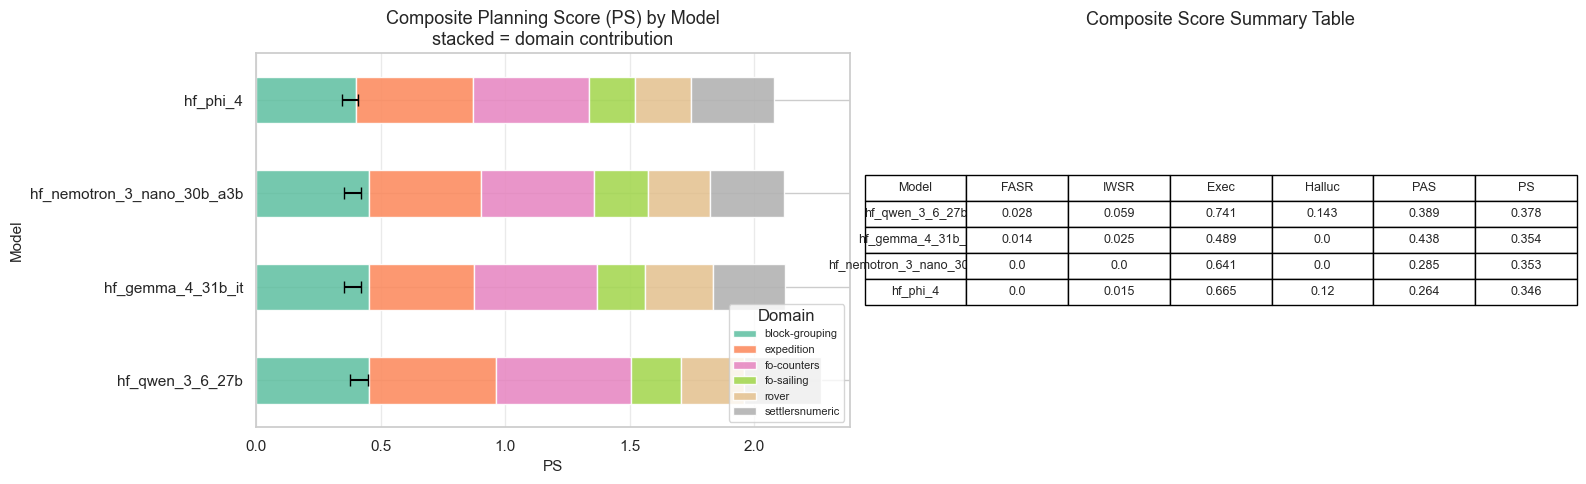

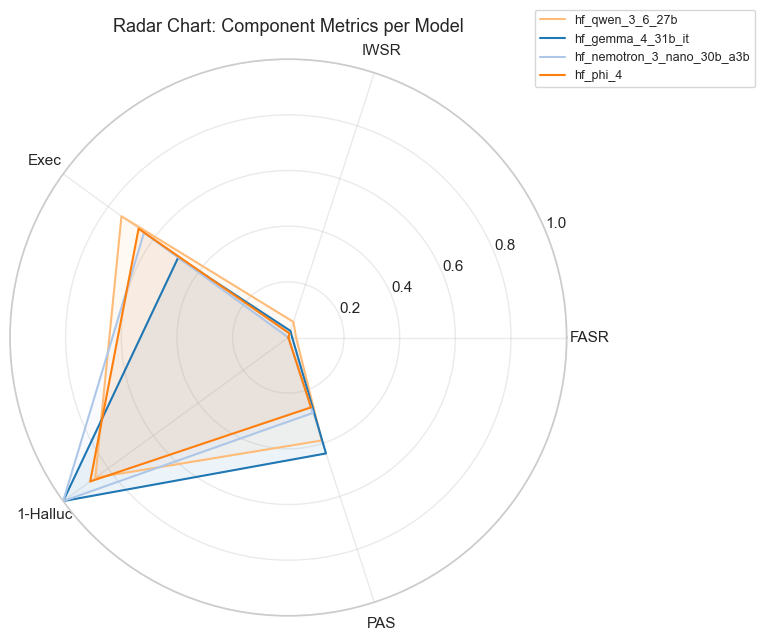

In [27]:

if df.empty or 'ps_overall' not in dir():
    print("No PS data.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    score_by_domain = ps_dom.pivot_table(values='PS', index='Model', columns='Domain').fillna(0)
    score_by_domain_sorted = score_by_domain.reindex(ps_overall['Model']).fillna(0)
    score_by_domain_sorted.plot(
        kind='barh',
        stacked=True,
        ax=axes[0],
        colormap='Set2',
        edgecolor='white',
        alpha=.9,
    )

    for row_index, (_, model_row) in enumerate(ps_overall.iterrows()):
        score = model_row['PS_overall']
        if not np.isfinite(score):
            continue

        left_error = model_row.get('err_lo', 0)
        right_error = model_row.get('err_hi', 0)
        left_error = max(float(left_error), 0.0) if np.isfinite(left_error) else 0.0
        right_error = max(float(right_error), 0.0) if np.isfinite(right_error) else 0.0

        axes[0].errorbar(
            score,
            row_index,
            xerr=[[left_error], [right_error]],
            fmt='none',
            color='black',
            capsize=4,
            linewidth=1.5,
        )

    axes[0].set_title('Composite Planning Score (PS) by Model\nstacked = domain contribution')
    axes[0].set_xlabel('PS')
    axes[0].set_ylabel('Model')
    axes[0].grid(axis='x', alpha=.4)
    axes[0].legend(title='Domain', fontsize=8, loc='lower right')

    axes[1].axis('off')
    summary_table = ps_dom.groupby('Model').agg(
        FASR=('fasr', 'mean'),
        IWSR=('iwsr', 'mean'),
        Exec=('exec_ratio', 'mean'),
        Halluc=('halluc', 'mean'),
        PAS=('pas', 'mean'),
        PS=('PS', 'mean'),
    ).round(3).sort_values('PS', ascending=False).reset_index()
    summary_table.columns = ['Model', 'FASR', 'IWSR', 'Exec', 'Halluc', 'PAS', 'PS']

    table_plot = axes[1].table(
        cellText=summary_table.values,
        colLabels=summary_table.columns,
        cellLoc='center',
        loc='center',
    )
    table_plot.auto_set_font_size(False)
    table_plot.set_fontsize(9)
    table_plot.scale(1.2, 1.6)
    axes[1].set_title('Composite Score Summary Table', pad=20)

    plt.tight_layout()
    plt.show()

    radar_metrics = ['FASR', 'IWSR', 'Exec', '1-Halluc', 'PAS']
    metric_count = len(radar_metrics)
    angles = np.linspace(0, 2 * np.pi, metric_count, endpoint=False).tolist()
    angles += angles[:1]

    fig3, ax3 = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    for _, model_row in summary_table.iterrows():
        metric_values = [
            model_row['FASR'],
            model_row['IWSR'],
            model_row['Exec'],
            1 - model_row['Halluc'],
            model_row['PAS'],
        ]
        if not np.isfinite(metric_values).all():
            continue

        metric_values += metric_values[:1]
        model_color = MODEL_PALETTE.get(model_row['Model'], 'gray')
        ax3.plot(angles, metric_values, linewidth=1.5, label=model_row['Model'], color=model_color)
        ax3.fill(angles, metric_values, alpha=.08, color=model_color)

    ax3.set_xticks(angles[:-1])
    ax3.set_xticklabels(radar_metrics, fontsize=11)
    ax3.set_ylim(0, 1)
    ax3.set_title('Radar Chart: Component Metrics per Model', fontsize=13, pad=20)
    ax3.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
    ax3.grid(alpha=.4)
    plt.tight_layout()
    plt.show()
